# Nghiên cứu và so sánh các thuật toán Học máy trong dự đoán nguy cơ bệnh tim mạch


## 1. Setup, seed, config tập trung

In [1]:
# === Imports ===
import os
import json
import time
import warnings
import platform
import hashlib
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import logit, expit
from scipy.stats import binom

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix,
    f1_score, fbeta_score, log_loss, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, learning_curve,
)

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import joblib

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

# Suppress 2 warning vô hại + noisy:
# 1. datetime.utcnow() deprecation từ jupyter_client internals (không từ code notebook)
# 2. "X does not have valid feature names" từ sklearn khi pipeline output ndarray
#    nhưng model như LightGBM/XGBoost được fit qua DataFrame schema.
warnings.filterwarnings("default")
warnings.filterwarnings(
    "ignore", category=UserWarning,
    message=".*does not have valid feature names.*",
)
warnings.filterwarnings(
    "ignore", category=DeprecationWarning,
    message=".*datetime.datetime.utcnow.*",
)

In [2]:
# === Seed + global timer ===
SEED = 42
np.random.seed(SEED)

NOTEBOOK_T0 = time.time()  # log tổng runtime ở phần cuối

# Bản Kaggle cải tiến: chạy lâu hơn để tìm hyperparameter kỹ hơn.
# Có thể override khi demo bảo vệ:
#   RUN_MODE=fast         -> chạy nhanh
#   RUN_MODE=final        -> bản nghiên cứu đầy đủ
#   RUN_MODE=kaggle_long  -> tìm kiếm/tái lập dài hơn
#   RUN_MODE=research_max -> ngân sách lớn nhất: research search + ensemble + early stopping
RUN_MODE = os.getenv("RUN_MODE", "final").strip().lower()
MODE_ALIASES = {
    "defense_fast": "fast",
    "presentation": "fast",
    "demo": "fast",
    "long": "kaggle_long",
    "research": "research_max",
    "researchmax": "research_max",
    "max": "research_max",
}
RUN_MODE = MODE_ALIASES.get(RUN_MODE, RUN_MODE)
VALID_RUN_MODES = {"debug", "fast", "final", "kaggle_long", "research_max"}
if RUN_MODE not in VALID_RUN_MODES:
    raise ValueError(f"RUN_MODE={RUN_MODE!r} không hợp lệ. Chọn một trong {sorted(VALID_RUN_MODES)}.")


CONFIG = {
    "target_col": "cardio",
    "id_col": "id",
    "random_state": SEED,

    # Split protocol
    "test_n_splits": 7,           # 1/7 ~ 14% test
    "val_pool_n_splits": 4,       # tách val pool khỏi non-test
    "use_fast_group_holdout": True,  # nhanh hơn SGKF holdout khi feature_signature gần-unique
    "debug_sample_rows": 12000,      # chỉ dùng trong RUN_MODE=debug
    "hard_require_group_split": True,
    "split_protocol": "5way_group_aware_train_val_cal_select_threshold_test",

    # Defense guardrails
    "forbid_test_set_model_selection": True,
    "pre_register_final_selection_rule": True,
    "primary_selection_metric": "selection_score_default_weights",
    "test_set_policy": "locked_final_reporting_only",

    # Clinical plausibility ranges
    "height_range_cm": (130.0, 220.0),
    "weight_range_kg": (30.0, 180.0),
    "ap_hi_range":     (80.0, 250.0),
    "ap_lo_range":     (40.0, 180.0),
    "bmi_range":       (10.0, 80.0),

    # Per-mode runtime knobs
    # final được chỉnh để đúng mô tả: 5-fold CV + nested CV 5x3
    "cv_folds":            {"debug": 3, "fast": 3, "final": 5, "kaggle_long": 7, "research_max": 10},
    "search_iter":         {"debug": 3, "fast": 8, "final": 25, "kaggle_long": 80, "research_max": 160},
    "max_tuned_models":    {"debug": 2, "fast": 3, "final": 5, "kaggle_long": 7, "research_max": 7},
    "bootstrap_rounds":    {"debug": 80, "fast": 150, "final": 600, "kaggle_long": 1200, "research_max": 2000},

    # Nested CV
    "nested_outer_folds":  {"debug": 2, "fast": 3, "final": 5, "kaggle_long": 5, "research_max": 5},
    "nested_inner_folds":  {"debug": 2, "fast": 3, "final": 3, "kaggle_long": 3, "research_max": 5},
    "nested_search_iter":  {"debug": 2, "fast": 5, "final": 10, "kaggle_long": 20, "research_max": 35},
    "max_nested_models":   {"debug": 1, "fast": 2, "final": 5, "kaggle_long": 5, "research_max": 5},

    # Model-size knobs
    "tree_n_estimators":     {"debug": 180, "fast": 300, "final": 350, "kaggle_long": 700, "research_max": 1200},
    "boosting_n_estimators": {"debug": 250, "fast": 350, "final": 450, "kaggle_long": 900, "research_max": 1800},
    "svm_max_iter":          {"debug": 5000, "fast": 8000, "final": 10000, "kaggle_long": 20000, "research_max": 30000},
    "logreg_max_iter":       {"debug": 2000, "fast": 3000, "final": 4000, "kaggle_long": 8000, "research_max": 12000},

    # Research-max additions
    "ensemble_top_k":        {"debug": 2, "fast": 3, "final": 3, "kaggle_long": 5, "research_max": 7},
    "enable_ensemble_top_models": True,
    "use_train_only_early_stopping": True,
    "early_stopping_rounds": {"debug": 20, "fast": 40, "final": 60, "kaggle_long": 100, "research_max": 150},
    "early_stopping_holdout_frac": 0.15,

    # Threshold tuning
    "specificity_floor": 0.60,
    "f_beta": 2.0,

    # Explainability
    "max_shap_samples": 1000,
    "max_permutation_samples": 2500,
    "n_shap_dependence": 6,
    "interaction_scatter_sample": 5000,
    "require_shap_for_final": False,

    # Search
    "random_search_scoring": "average_precision",
    "random_search_n_jobs": 1,

    # Robustness studies
    "run_nested_cv": True,
    "run_ablation_study": True,
    "run_multi_seed_robustness": True,
    "multi_seed_values": [42, 2024, 2026],
    "run_cleaning_sensitivity": True,
    "run_cost_sensitive_threshold": True,
    "cost_fn_to_fp_ratio": 5.0,

    # Selection score weight robustness
    "selection_weight_scenarios": [
        {"name": "default",     "auc": 0.45, "pr": 0.35, "brier": 0.20, "ece": 0.05},
        {"name": "auc_heavy",   "auc": 0.55, "pr": 0.30, "brier": 0.10, "ece": 0.05},
        {"name": "pr_heavy",    "auc": 0.30, "pr": 0.50, "brier": 0.15, "ece": 0.05},
        {"name": "calib_heavy", "auc": 0.30, "pr": 0.30, "brier": 0.30, "ece": 0.10},
        {"name": "balanced",    "auc": 0.40, "pr": 0.40, "brier": 0.15, "ece": 0.05},
    ],

    # Cleaning sensitivity scenarios
    "cleaning_sensitivity_scenarios": [
        {"scenario": "current",  "height": (130.0, 220.0), "weight": (30.0, 180.0),
         "ap_hi": (80.0, 250.0), "ap_lo": (40.0, 180.0), "bmi": (10.0, 80.0)},
        {"scenario": "loose",    "height": (120.0, 230.0), "weight": (25.0, 200.0),
         "ap_hi": (70.0, 260.0), "ap_lo": (35.0, 190.0), "bmi": (8.0, 90.0)},
        {"scenario": "strict",   "height": (140.0, 210.0), "weight": (35.0, 160.0),
         "ap_hi": (90.0, 220.0), "ap_lo": (50.0, 140.0), "bmi": (12.0, 65.0)},
    ],
}


# Official data dictionary mapping.
# Cardiovascular Disease Dataset/Sulianova: gender 1 = women, 2 = men.
# Cell audit bên dưới chỉ dùng chiều cao để sanity-check, KHÔNG đảo nhãn.
GENDER_LABELS = {1: "women", 2: "men"}
GENDER_LABELS_VI = {1: "nữ", 2: "nam"}
GENDER_DICTIONARY_NOTE = "Official mapping: gender 1 = women, 2 = men."

# Ý nghĩa mã ordinal theo data dictionary của dataset Sulianova/Kaggle.
# Model vẫn dùng cột số 1/2/3 để giữ thứ tự ordinal; phần EDA/report dùng label này cho dễ đọc.
ORDINAL_MEDICAL_LEVELS = {
    "cholesterol": {
        1: "1 = bình thường",
        2: "2 = cao hơn bình thường",
        3: "3 = rất cao",
    },
    "gluc": {
        1: "1 = bình thường",
        2: "2 = cao hơn bình thường",
        3: "3 = rất cao",
    },
}
ORDINAL_MEDICAL_DISPLAY_NAME = {
    "cholesterol": "Cholesterol",
    "gluc": "Glucose",
}

# Nguồn gốc của mã 1/2/3:
# - Đây là mã ordinal đã có sẵn trong data dictionary của Cardiovascular Disease dataset.
# - Dataset KHÔNG cung cấp giá trị xét nghiệm gốc theo mg/dL cho từng bệnh nhân.
# - Vì vậy, ngưỡng mg/dL bên dưới chỉ là ngưỡng tham khảo y khoa để giải thích,
#   không phải giá trị đo trực tiếp của từng dòng dữ liệu.
ORDINAL_LEVEL_SOURCE_NOTE = (
    "Dataset mã hoá sẵn cholesterol/gluc dạng ordinal: "
    "1=normal, 2=above normal, 3=well above normal; "
    "không có số xét nghiệm gốc theo mg/dL."
)

CLINICAL_CUTOFF_REFERENCE = {
    "cholesterol": {
        1: {
            "clinical_variable": "Total cholesterol",
            "clinical_cutoff_reference": "< 200 mg/dL",
            "clinical_interpretation_vi": "bình thường / mong muốn",
            "reference_source": "UCSF Health total cholesterol; American Heart Association cholesterol guidance",
        },
        2: {
            "clinical_variable": "Total cholesterol",
            "clinical_cutoff_reference": "200–239 mg/dL",
            "clinical_interpretation_vi": "cao hơn bình thường / borderline high",
            "reference_source": "UCSF Health total cholesterol; American Heart Association cholesterol guidance",
        },
        3: {
            "clinical_variable": "Total cholesterol",
            "clinical_cutoff_reference": "≥ 240 mg/dL",
            "clinical_interpretation_vi": "cao / rất cao",
            "reference_source": "UCSF Health total cholesterol; American Heart Association cholesterol guidance",
        },
    },
    "gluc": {
        1: {
            "clinical_variable": "Fasting blood glucose",
            "clinical_cutoff_reference": "≤ 99 mg/dL",
            "clinical_interpretation_vi": "bình thường",
            "reference_source": "CDC Diabetes Testing - fasting blood sugar test",
        },
        2: {
            "clinical_variable": "Fasting blood glucose",
            "clinical_cutoff_reference": "100–125 mg/dL",
            "clinical_interpretation_vi": "cao hơn bình thường / tiền đái tháo đường",
            "reference_source": "CDC Diabetes Testing - fasting blood sugar test",
        },
        3: {
            "clinical_variable": "Fasting blood glucose",
            "clinical_cutoff_reference": "≥ 126 mg/dL",
            "clinical_interpretation_vi": "rất cao / ngưỡng đái tháo đường",
            "reference_source": "CDC Diabetes Testing - fasting blood sugar test",
        },
    },
}


def clinical_cutoff_label(feature: str, value) -> str:
    """Trả về ngưỡng y khoa tham khảo cho level 1/2/3; fallback an toàn cho missing/invalid."""
    if feature not in CLINICAL_CUTOFF_REFERENCE:
        return ""
    if pd.isna(value):
        return "missing"
    try:
        value_int = int(value)
    except Exception:
        return f"invalid: {value}"
    info = CLINICAL_CUTOFF_REFERENCE[feature].get(value_int)
    if info is None:
        return f"invalid: {value_int}"
    return info["clinical_cutoff_reference"]


def medical_level_label(feature: str, value) -> str:
    """Trả về label rõ nghĩa cho cholesterol/gluc; giữ fallback an toàn cho missing/invalid."""
    if feature not in ORDINAL_MEDICAL_LEVELS:
        return str(value)
    if pd.isna(value):
        return "missing"
    try:
        value_int = int(value)
    except Exception:
        return f"invalid: {value}"
    return ORDINAL_MEDICAL_LEVELS[feature].get(value_int, f"invalid: {value_int}")


def add_medical_level_labels(df: pd.DataFrame, columns=("cholesterol", "gluc")) -> pd.DataFrame:
    """Thêm cột *_level_label để bảng/biểu đồ thể hiện rõ 1/2/3 là gì."""
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[f"{col}_level_label"] = out[col].map(lambda v: medical_level_label(col, v))
    return out


def cfg_for_mode(key):
    return CONFIG[key][RUN_MODE]


CV_FOLDS              = cfg_for_mode("cv_folds")
N_RANDOM_SEARCH_ITER  = cfg_for_mode("search_iter")
MAX_TUNED_MODELS      = cfg_for_mode("max_tuned_models")
N_BOOTSTRAP           = cfg_for_mode("bootstrap_rounds")
NESTED_OUTER_FOLDS    = cfg_for_mode("nested_outer_folds")
NESTED_INNER_FOLDS    = cfg_for_mode("nested_inner_folds")
NESTED_N_SEARCH_ITER  = cfg_for_mode("nested_search_iter")
MAX_NESTED_MODELS     = cfg_for_mode("max_nested_models")
TREE_N_ESTIMATORS     = cfg_for_mode("tree_n_estimators")
BOOSTING_N_ESTIMATORS = cfg_for_mode("boosting_n_estimators")
SVM_MAX_ITER          = cfg_for_mode("svm_max_iter")
LOGREG_MAX_ITER       = cfg_for_mode("logreg_max_iter")
ENSEMBLE_TOP_K        = cfg_for_mode("ensemble_top_k")
EARLY_STOPPING_ROUNDS = cfg_for_mode("early_stopping_rounds")
EARLY_STOPPING_HOLDOUT_FRAC = CONFIG["early_stopping_holdout_frac"]

# Giới hạn song song trong debug/local để tránh spawn quá nhiều process.
N_JOBS = 1 if RUN_MODE == "debug" else -1

# Debug mode chỉ để smoke-test nhanh; final/kaggle_long vẫn chạy đầy đủ.
if RUN_MODE == "debug":
    CONFIG["run_nested_cv"] = False
    CONFIG["run_ablation_study"] = False
    CONFIG["run_multi_seed_robustness"] = False
    CONFIG["run_cleaning_sensitivity"] = False
    CONFIG["max_shap_samples"] = min(CONFIG["max_shap_samples"], 250)
    CONFIG["max_permutation_samples"] = min(CONFIG["max_permutation_samples"], 600)
    CONFIG["n_shap_dependence"] = min(CONFIG["n_shap_dependence"], 3)


print("RUN_MODE:", RUN_MODE)
print("CV_FOLDS:", CV_FOLDS,
      "| SEARCH_ITER:", N_RANDOM_SEARCH_ITER,
      "| MAX_TUNED:", MAX_TUNED_MODELS,
      "| BOOTSTRAP:", N_BOOTSTRAP,
      "| TREE_N:", TREE_N_ESTIMATORS,
      "| BOOSTING_N:", BOOSTING_N_ESTIMATORS,
      "| ENSEMBLE_TOP_K:", ENSEMBLE_TOP_K,
      "| EARLY_STOP:", EARLY_STOPPING_ROUNDS)
print("Cholesterol/Glucose levels:", ORDINAL_MEDICAL_LEVELS)


RUN_MODE: final
CV_FOLDS: 5 | SEARCH_ITER: 25 | MAX_TUNED: 5 | BOOTSTRAP: 600 | TREE_N: 350 | BOOSTING_N: 450 | ENSEMBLE_TOP_K: 3 | EARLY_STOP: 60
Cholesterol/Glucose levels: {'cholesterol': {1: '1 = bình thường', 2: '2 = cao hơn bình thường', 3: '3 = rất cao'}, 'gluc': {1: '1 = bình thường', 2: '2 = cao hơn bình thường', 3: '3 = rất cao'}}


In [3]:
# === Data path with fallback chain ===
DATA_CANDIDATES = [
    Path("/kaggle/input/cardiovascular-disease-dataset/cardio_train.csv"),
    Path("/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv"),
    Path("/mnt/user-data/uploads/cardio_train.csv"),
    Path("/mnt/data/cardio_train.csv"),
    Path("cardio_train.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy cardio_train.csv. "
        "Đường dẫn đã thử: " + " | ".join(str(p) for p in DATA_CANDIDATES)
    )

# === Artifact directories ===
if Path("/kaggle/working").exists():
    ARTIFACT_DIR = Path("/kaggle/working/cardio_artifacts")
else:
    ARTIFACT_DIR = Path("./cardio_artifacts")

FIG_DIR   = ARTIFACT_DIR / "figures"
TABLE_DIR = ARTIFACT_DIR / "tables"
MODEL_DIR = ARTIFACT_DIR / "models"
for d in [ARTIFACT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("ARTIFACT_DIR:", ARTIFACT_DIR)

DATA_PATH: /kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv
ARTIFACT_DIR: /kaggle/working/cardio_artifacts


In [4]:
# === Helpers: IO + library versions ===
def save_json(obj: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)


def save_df(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index, encoding="utf-8-sig")




def stable_json_sha256(obj: Any) -> str:
    """Hash ổn định cho audit pre-test: dùng để chứng minh selection protocol đã khóa."""
    payload = json.dumps(obj, ensure_ascii=False, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def stable_dataframe_sha256(df: pd.DataFrame) -> str:
    """Hash bảng theo nội dung, không phụ thuộc index hiện tại."""
    safe_df = df.copy()
    safe_df = safe_df.reindex(sorted(safe_df.columns), axis=1)
    payload = safe_df.to_csv(index=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

def make_ohe():
    """OneHotEncoder tương thích nhiều phiên bản sklearn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def sigmoid_clip(p, eps=1e-6):
    return np.clip(np.asarray(p, dtype=float), eps, 1 - eps)



def _to_builtin_clone_param(value):
    """Convert numpy scalar params to Python builtins and recursively sanitize estimators.

    Một số estimator ngoài sklearn (đặc biệt CatBoost sau RandomizedSearchCV)
    có thể giữ hyperparameter dưới dạng np.float64/np.int64. sklearn.clone()
    kiểm tra identity của parameter và sẽ crash với lỗi "constructor modifies
    parameter ...". Helper này chuyển tham số về Python scalar để các study
    robustness/ablation có thể clone model ổn định.
    """
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {k: _to_builtin_clone_param(v) for k, v in value.items()}
    if isinstance(value, list):
        return [_to_builtin_clone_param(v) for v in value]
    if isinstance(value, tuple):
        return tuple(_to_builtin_clone_param(v) for v in value)
    if hasattr(value, "get_params") and hasattr(value, "set_params"):
        return safe_clone_estimator(value)
    return value


def safe_clone_estimator(estimator_obj):
    """sklearn.clone() + fallback sửa numpy scalar params cho CatBoost/XGBoost/LightGBM.

    Trả về estimator chưa fit, clone-compatible. Dùng thay clone(...) ở các
    pipeline phụ như learning curve, ablation, cleaning sensitivity, multi-seed.
    """
    try:
        return clone(estimator_obj)
    except RuntimeError as err:
        msg = str(err)
        clone_param_error = (
            "Cannot clone object" in msg
            or "constructor either does not set or modifies parameter" in msg
        )
        if not clone_param_error or not hasattr(estimator_obj, "get_params"):
            raise

        params = estimator_obj.get_params(deep=False)
        safe_params = {k: _to_builtin_clone_param(v) for k, v in params.items()}
        rebuilt = estimator_obj.__class__(**safe_params)

        # Verify ngay để lỗi thật không bị che khuất.
        return clone(rebuilt)

def get_library_versions() -> Dict[str, Any]:
    versions = {
        "created_at": datetime.now().isoformat(),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
    }
    for lib in ["sklearn", "scipy", "joblib", "matplotlib",
                "xgboost", "lightgbm", "catboost", "shap"]:
        try:
            module = __import__(lib)
            versions[lib] = getattr(module, "__version__", "unknown")
        except Exception as e:
            versions[lib] = f"NOT_AVAILABLE: {type(e).__name__}"
    return versions


env_info = get_library_versions()
save_json(env_info, ARTIFACT_DIR / "library_versions.json")

run_config = {
    "created_at": datetime.now().isoformat(),
    "seed": SEED,
    "run_mode": RUN_MODE,
    "data_path": str(DATA_PATH),
    "artifact_dir": str(ARTIFACT_DIR),
    "config": CONFIG,
    "derived": {
        "cv_folds": CV_FOLDS,
        "search_iter": N_RANDOM_SEARCH_ITER,
        "max_tuned_models": MAX_TUNED_MODELS,
        "n_bootstrap": N_BOOTSTRAP,
        "nested_outer_folds": NESTED_OUTER_FOLDS,
        "nested_inner_folds": NESTED_INNER_FOLDS,
        "tree_n_estimators": TREE_N_ESTIMATORS,
        "boosting_n_estimators": BOOSTING_N_ESTIMATORS,
        "svm_max_iter": SVM_MAX_ITER,
        "logreg_max_iter": LOGREG_MAX_ITER,
        "ensemble_top_k": ENSEMBLE_TOP_K,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "early_stopping_holdout_frac": EARLY_STOPPING_HOLDOUT_FRAC,
        "n_jobs": N_JOBS,
    },
    "leakage_guardrails": [
        "Split before any preprocessing/feature engineering fit.",
        "All preprocessing and FE are inside sklearn Pipeline.",
        "Calibration, model selection, threshold tuning, and final test use separate splits.",
        "Test set is locked and is never used for model/threshold/calibrator selection.",
        "Group-aware split by feature_signature prevents duplicate-row leakage.",
    ],
}
save_json(run_config, ARTIFACT_DIR / "run_config.json")
print(json.dumps({k: env_info[k] for k in
                  ["python", "numpy", "pandas", "sklearn", "scipy", "shap",
                   "xgboost", "lightgbm", "catboost"]
                  if k in env_info}, indent=2, ensure_ascii=False))


{
  "python": "3.12.12",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "sklearn": "1.6.1",
  "scipy": "1.16.3",
  "shap": "0.50.0",
  "xgboost": "3.2.0",
  "lightgbm": "4.6.0",
  "catboost": "1.2.10"
}


## 2. Load dữ liệu + kiểm tra schema, dtype, domain



In [5]:
def read_cardio_csv(path: Path) -> pd.DataFrame:
    df_try = pd.read_csv(path, sep=";")
    if df_try.shape[1] == 1:
        raise ValueError("Sulianova phải đọc bằng separator=';'.")
    return df_try


EXPECTED_COLUMNS = [
    "id", "age", "gender", "height", "weight", "ap_hi", "ap_lo",
    "cholesterol", "gluc", "smoke", "alco", "active", "cardio",
]

DOMAIN_RULES = {
    "gender": {1, 2},
    "cholesterol": {1, 2, 3},
    "gluc": {1, 2, 3},
    "smoke": {0, 1},
    "alco": {0, 1},
    "active": {0, 1},
    "cardio": {0, 1},
}

raw_df = read_cardio_csv(DATA_PATH)
if list(raw_df.columns) != EXPECTED_COLUMNS:
    raise ValueError(f"Sai schema. Expected={EXPECTED_COLUMNS}; got={list(raw_df.columns)}")

# dtype check: tất cả numeric; integer-like (trừ weight)
non_numeric = [c for c in EXPECTED_COLUMNS if not pd.api.types.is_numeric_dtype(raw_df[c])]
if non_numeric:
    raise TypeError(f"Cột phải là numeric: {non_numeric}")

int_like_cols = [c for c in EXPECTED_COLUMNS if c != "weight"]
bad_int = [c for c in int_like_cols if not np.allclose(raw_df[c], np.round(raw_df[c]))]
if bad_int:
    raise TypeError(f"Cột phải là integer-like: {bad_int}")

schema_report = pd.DataFrame({
    "column": raw_df.columns,
    "dtype": [str(raw_df[c].dtype) for c in raw_df.columns],
    "n_missing": [int(raw_df[c].isna().sum()) for c in raw_df.columns],
    "missing_rate": [float(raw_df[c].isna().mean()) for c in raw_df.columns],
    "n_unique": [int(raw_df[c].nunique(dropna=False)) for c in raw_df.columns],
})
save_df(schema_report, TABLE_DIR / "01_raw_schema_report.csv")
display(raw_df.head())
display(schema_report)
print("Raw shape:", raw_df.shape, "| Schema + dtype contract: PASS")

# DEBUG MODE SAMPLE: chỉ smoke-test nhanh; RUN_MODE=final/kaggle_long dùng đủ dataset.
if RUN_MODE == "debug" and len(raw_df) > int(CONFIG.get("debug_sample_rows", 0)):
    sample_n = int(CONFIG["debug_sample_rows"])
    before_shape = tuple(raw_df.shape)
    raw_df = (
        raw_df.groupby(CONFIG["target_col"], group_keys=False)
        .sample(n=sample_n // 2, random_state=SEED)
        .sort_index()
        .reset_index(drop=True)
    )
    debug_sample_audit = {
        "status": "debug_sample_applied",
        "full_shape_before_debug_sample": before_shape,
        "debug_shape_after_sample": tuple(raw_df.shape),
        "class_balance_after_sample": raw_df[CONFIG["target_col"]].value_counts(normalize=True).to_dict(),
        "note": "Chỉ áp dụng trong RUN_MODE=debug; bản final dùng toàn bộ dataset.",
    }
    save_json(debug_sample_audit, TABLE_DIR / "00_debug_sample_audit.json")
    print("[DEBUG MODE SAMPLE]", json.dumps(debug_sample_audit, ensure_ascii=False, indent=2))

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


,column,dtype,n_missing,missing_rate,n_unique
0,id,int64,0,0.0,70000
1,age,int64,0,0.0,8076
2,gender,int64,0,0.0,2
3,height,int64,0,0.0,109
4,weight,float64,0,0.0,287
5,ap_hi,int64,0,0.0,153
6,ap_lo,int64,0,0.0,157
7,cholesterol,int64,0,0.0,3
8,gluc,int64,0,0.0,3
9,smoke,int64,0,0.0,2


Raw shape: (70000, 13) | Schema + dtype contract: PASS


In [6]:
# === Domain validation: fail-fast nếu cột nhị phân/ordinal có giá trị ngoài domain ===
domain_rows = []
for col in ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]:
    vc = raw_df[col].value_counts(dropna=False).sort_index()
    allowed = DOMAIN_RULES[col]
    for value, count in vc.items():
        domain_rows.append({
            "column": col,
            "value": value,
            "level_label": medical_level_label(col, value) if col in ORDINAL_MEDICAL_LEVELS else "",
            "clinical_cutoff_reference": clinical_cutoff_label(col, value) if col in ORDINAL_MEDICAL_LEVELS else "",
            "count": int(count),
            "ratio": float(count / len(raw_df)),
            "allowed": sorted(list(allowed)),
            "is_valid": bool(value in allowed),
        })

domain_value_report = pd.DataFrame(domain_rows)
save_df(domain_value_report, TABLE_DIR / "01_domain_value_report.csv")
display(domain_value_report)

# Bảng riêng cho 2 biến ordinal y khoa để đưa thẳng vào báo cáo.
# Cột dataset_level_label là ý nghĩa mã trong dataset; cột clinical_cutoff_reference là ngưỡng y khoa tham khảo.
ordinal_level_reference_rows = []
for feature, mapping in ORDINAL_MEDICAL_LEVELS.items():
    for code, label in mapping.items():
        clinical_info = CLINICAL_CUTOFF_REFERENCE[feature][code]
        ordinal_level_reference_rows.append({
            "feature": feature,
            "feature_display_name": ORDINAL_MEDICAL_DISPLAY_NAME.get(feature, feature),
            "level_code": code,
            "dataset_level_label": label,
            "clinical_variable": clinical_info["clinical_variable"],
            "clinical_cutoff_reference": clinical_info["clinical_cutoff_reference"],
            "clinical_interpretation_vi": clinical_info["clinical_interpretation_vi"],
            "reference_source": clinical_info["reference_source"],
            "important_note": ORDINAL_LEVEL_SOURCE_NOTE,
        })

ordinal_level_reference = pd.DataFrame(ordinal_level_reference_rows)
save_df(ordinal_level_reference, TABLE_DIR / "01_ordinal_medical_level_reference.csv")
save_df(ordinal_level_reference, TABLE_DIR / "01_cholesterol_glucose_level_cutoff_reference.csv")
display(ordinal_level_reference)

raw_audit = {
    "n_rows": int(len(raw_df)),
    "n_cols": int(raw_df.shape[1]),
    "target_distribution": raw_df[CONFIG["target_col"]].value_counts().to_dict(),
    "duplicated_full_rows": int(raw_df.duplicated().sum()),
}
save_json(raw_audit, TABLE_DIR / "01_raw_audit.json")

invalid_rows = domain_value_report[~domain_value_report["is_valid"]]
if len(invalid_rows):
    save_df(invalid_rows, TABLE_DIR / "01_domain_invalid_rows.csv")
    raise ValueError(f"Domain violation:\n{invalid_rows.to_string(index=False)}")
print("Domain contract: PASS")
print(f"Class balance: {raw_df['cardio'].value_counts(normalize=True).to_dict()}")


,column,value,level_label,clinical_cutoff_reference,count,ratio,allowed,is_valid
0,gender,1,,,45530,0.650429,"[1, 2]",True
1,gender,2,,,24470,0.349571,"[1, 2]",True
2,cholesterol,1,1 = bình thường,< 200 mg/dL,52385,0.748357,"[1, 2, 3]",True
3,cholesterol,2,2 = cao hơn bình thường,200–239 mg/dL,9549,0.136414,"[1, 2, 3]",True
4,cholesterol,3,3 = rất cao,≥ 240 mg/dL,8066,0.115229,"[1, 2, 3]",True
5,gluc,1,1 = bình thường,≤ 99 mg/dL,59479,0.849700,"[1, 2, 3]",True
6,gluc,2,2 = cao hơn bình thường,100–125 mg/dL,5190,0.074143,"[1, 2, 3]",True
7,gluc,3,3 = rất cao,≥ 126 mg/dL,5331,0.076157,"[1, 2, 3]",True
8,smoke,0,,,63831,0.911871,"[0, 1]",True
9,smoke,1,,,6169,0.088129,"[0, 1]",True


,feature,feature_display_name,level_code,dataset_level_label,clinical_variable,clinical_cutoff_reference,clinical_interpretation_vi,reference_source,important_note
0,cholesterol,Cholesterol,1,1 = bình thường,Total cholesterol,< 200 mg/dL,bình thường / mong muốn,UCSF Health total cholesterol; American Heart ...,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
1,cholesterol,Cholesterol,2,2 = cao hơn bình thường,Total cholesterol,200–239 mg/dL,cao hơn bình thường / borderline high,UCSF Health total cholesterol; American Heart ...,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
2,cholesterol,Cholesterol,3,3 = rất cao,Total cholesterol,≥ 240 mg/dL,cao / rất cao,UCSF Health total cholesterol; American Heart ...,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
3,gluc,Glucose,1,1 = bình thường,Fasting blood glucose,≤ 99 mg/dL,bình thường,CDC Diabetes Testing - fasting blood sugar test,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
4,gluc,Glucose,2,2 = cao hơn bình thường,Fasting blood glucose,100–125 mg/dL,cao hơn bình thường / tiền đái tháo đường,CDC Diabetes Testing - fasting blood sugar test,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
5,gluc,Glucose,3,3 = rất cao,Fasting blood glucose,≥ 126 mg/dL,rất cao / ngưỡng đái tháo đường,CDC Diabetes Testing - fasting blood sugar test,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...


Domain contract: PASS
Class balance: {0: 0.5003, 1: 0.4997}


## 3. Audit gender + duplicate + label conflict (KHÔNG drop bằng target trước split)

`gender` mã hóa 1/2 (không khẳng định nhãn nam/nữ — phải suy luận từ chiều cao trung vị).

`feature_signature` (chuỗi join toàn bộ feature **không gồm `id` và `cardio`**) dùng để:
1. Audit số duplicate / conflict label.
2. Làm `group` cho `StratifiedGroupKFold` → đảm bảo cùng signature không lọt vào nhiều split/fold.

**Không** xóa nhóm conflict bằng cách nhìn `cardio` trước split — đó là target-informed cleaning, sẽ tạo leakage.

In [7]:

# Official gender mapping + sanity check bằng chiều cao
# Data dictionary chính thức: gender 1 = women, gender 2 = men.
# Chiều cao chỉ dùng để sanity-check tính hợp lý của nhãn, không dùng để suy luận/đảo nhãn.
gender_height_audit = (
    raw_df.groupby("gender")["height"]
    .agg(n="size", mean="mean", median="median", std="std", min="min", max="max")
    .reset_index()
)
gender_height_audit["official_label_en"] = gender_height_audit["gender"].map(GENDER_LABELS)
gender_height_audit["official_label_vi"] = gender_height_audit["gender"].map(GENDER_LABELS_VI)
gender_height_audit = gender_height_audit[
    ["gender", "official_label_en", "official_label_vi", "n", "mean", "median", "std", "min", "max"]
]
save_df(gender_height_audit, TABLE_DIR / "02_gender_height_audit.csv")
display(gender_height_audit)

# Sanity check: nhóm được mã hoá là men kỳ vọng có median height cao hơn women.
try:
    median_by_code = gender_height_audit.set_index("gender")["median"].to_dict()
    sanity_pass = bool(median_by_code.get(2, np.nan) > median_by_code.get(1, np.nan))
except Exception:
    sanity_pass = False

gender_note = {
    "official_mapping": GENDER_LABELS,
    "official_mapping_vi": GENDER_LABELS_VI,
    "sanity_check": "median_height_gender_2_greater_than_gender_1",
    "sanity_pass": sanity_pass,
    "interpretation": (
        "Notebook dùng mapping chính thức 1=women, 2=men. "
        "Sanity check bằng chiều cao chỉ để phát hiện lỗi dữ liệu nếu có, "
        "không phải cơ sở để đảo nhãn."
    ),
}
save_json(gender_note, TABLE_DIR / "02_gender_audit_note.json")
print(json.dumps(gender_note, ensure_ascii=False, indent=2))


,gender,official_label_en,official_label_vi,n,mean,median,std,min,max
0,1,women,nữ,45530,161.355612,161.0,7.052726,55,250
1,2,men,nam,24470,169.947895,170.0,7.228895,65,207


{
  "official_mapping": {
    "1": "women",
    "2": "men"
  },
  "official_mapping_vi": {
    "1": "nữ",
    "2": "nam"
  },
  "sanity_check": "median_height_gender_2_greater_than_gender_1",
  "sanity_pass": true,
  "interpretation": "Notebook dùng mapping chính thức 1=women, 2=men. Sanity check bằng chiều cao chỉ để phát hiện lỗi dữ liệu nếu có, không phải cơ sở để đảo nhãn."
}


In [8]:
# === feature_signature + audit duplicate/conflict ===
TARGET = CONFIG["target_col"]
ID_COL = CONFIG["id_col"] if CONFIG["id_col"] in raw_df.columns else None
feature_cols_for_signature = [c for c in raw_df.columns if c not in [TARGET, ID_COL]]

work_df = raw_df.copy()
work_df["feature_signature"] = (
    work_df[feature_cols_for_signature].astype(str).agg("|".join, axis=1)
)

full_dup_count = int(
    work_df.duplicated(subset=[c for c in raw_df.columns if c != ID_COL]).sum()
)

feature_group_report = (
    work_df.groupby("feature_signature")
    .agg(
        n_rows=(TARGET, "size"),
        n_unique_target=(TARGET, "nunique"),
        target_values=(TARGET, lambda s: sorted(s.dropna().unique().tolist())),
    )
    .reset_index()
)
conflict_groups = feature_group_report.query("n_unique_target > 1").copy()
conflict_rows = work_df[work_df["feature_signature"].isin(conflict_groups["feature_signature"])]

print("Duplicate full-row (excluding id):", full_dup_count)
print("Số nhóm feature trùng nhưng cardio mâu thuẫn:", len(conflict_groups))
print("Số dòng trong nhóm conflict:", len(conflict_rows))

save_df(conflict_groups.head(500), TABLE_DIR / "02_conflicting_groups.csv")

duplicate_strategy = {
    "rows_before": int(len(work_df)),
    "rows_used_for_modeling": int(len(work_df)),
    "rows_removed_before_split": 0,
    "duplicate_full_row_excluding_id": full_dup_count,
    "conflict_group_count": int(len(conflict_groups)),
    "conflict_row_count": int(len(conflict_rows)),
    "strategy": (
        "Audit only. Conflict groups handled by group-aware split via "
        "feature_signature, NOT by target-informed deletion."
    ),
    "leakage_note": (
        "Dropping conflict signatures using cardio before split = target leakage. "
        "We isolate conflicts by group split instead."
    ),
}
save_json(duplicate_strategy, TABLE_DIR / "02_duplicate_strategy.json")

df = work_df.copy().reset_index(drop=True)
print(json.dumps(duplicate_strategy, ensure_ascii=False, indent=2))

Duplicate full-row (excluding id): 24
Số nhóm feature trùng nhưng cardio mâu thuẫn: 17
Số dòng trong nhóm conflict: 34
{
  "rows_before": 70000,
  "rows_used_for_modeling": 70000,
  "rows_removed_before_split": 0,
  "duplicate_full_row_excluding_id": 24,
  "conflict_group_count": 17,
  "conflict_row_count": 34,
  "strategy": "Audit only. Conflict groups handled by group-aware split via feature_signature, NOT by target-informed deletion.",
  "leakage_note": "Dropping conflict signatures using cardio before split = target leakage. We isolate conflicts by group split instead."
}


## 4. Tách train / val_cal / val_select / val_threshold / test (group-aware)

Vai trò 5 split:

| Split | Mục đích |
|---|---|
| `train` | Fit model, fit preprocessing, hyperparameter search |
| `val_cal` | Fit calibrator (Platt / Isotonic) |
| `val_select` | Chọn model + calibrator (selection score) |
| `val_threshold` | Tune threshold (F2 + specificity floor) |
| `test` | Khóa, chỉ chạm 1 lần ở §15 để báo cáo cuối |

Group-aware: dùng `StratifiedGroupKFold` với `feature_signature` làm group → cùng signature không lọt vào nhiều split. Có assertion `n_group_overlap = 0` cho mọi cặp split.

In [9]:
USE_GROUP_SPLIT = bool(CONFIG["hard_require_group_split"] and HAS_STRATIFIED_GROUP_KFOLD)
if CONFIG["hard_require_group_split"] and not HAS_STRATIFIED_GROUP_KFOLD:
    print("[WARN] sklearn không có StratifiedGroupKFold; fallback StratifiedShuffleSplit.")

y_all = df[TARGET].astype(int).reset_index(drop=True)
X_all = df.drop(columns=[TARGET]).reset_index(drop=True)
groups_all = df["feature_signature"].astype(str).reset_index(drop=True)

# Drop id + feature_signature khỏi X model
DROP_FROM_MODEL = [c for c in [ID_COL, "feature_signature"]
                   if c is not None and c in X_all.columns]
X_model_all = X_all.drop(columns=DROP_FROM_MODEL)

assert TARGET not in X_model_all.columns
assert "feature_signature" not in X_model_all.columns
if ID_COL is not None:
    assert ID_COL not in X_model_all.columns

split_protocol = {
    "protocol": CONFIG["split_protocol"],
    "use_group_split": USE_GROUP_SPLIT,
    "group_column": "feature_signature",
    "dropped_from_model": DROP_FROM_MODEL,
    "n_rows_modeling": int(len(X_model_all)),
    "n_unique_groups": int(groups_all.nunique()),
    "positive_rate": float(y_all.mean()),
}
save_json(split_protocol, TABLE_DIR / "03_split_protocol.json")
print(f"X_model: {X_model_all.shape} | unique groups: {groups_all.nunique():,} "
      f"| positive_rate: {y_all.mean():.4f}")

X_model: (70000, 11) | unique groups: 69,959 | positive_rate: 0.4997


In [10]:
def fast_stratified_group_holdout(y, n_splits, seed, groups):
    """Fast group-aware, approximately stratified holdout.

    Preserves no group overlap by sampling groups (feature_signature), not rows.
    Stratifies on group-level majority target and chooses the best of several random trials
    by positive-rate/size balance. This is much faster than StratifiedGroupKFold on near-unique groups.
    """
    y = pd.Series(y).reset_index(drop=True).astype(int)
    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    row_df = pd.DataFrame({"row_idx": np.arange(len(y)), "group": groups, "y": y})
    group_df = (
        row_df.groupby("group", sort=False)
        .agg(n_rows=("y", "size"), n_pos=("y", "sum"))
        .reset_index()
    )
    group_df["target_rate"] = group_df["n_pos"] / group_df["n_rows"]
    group_df["group_label"] = (group_df["target_rate"] >= 0.5).astype(int)

    target_frac = 1.0 / n_splits
    target_n = len(y) * target_frac
    target_pos = float(y.mean())
    best = None
    for attempt in range(80):
        try:
            splitter = StratifiedShuffleSplit(n_splits=1, test_size=target_frac,
                                               random_state=seed + attempt)
            _, hold_group_pos = next(splitter.split(np.zeros(len(group_df)),
                                                    group_df["group_label"]))
        except ValueError:
            rng = np.random.default_rng(seed + attempt)
            hold_group_pos = rng.choice(
                len(group_df), size=max(1, int(round(len(group_df) * target_frac))), replace=False
            )
        hold_groups = set(group_df.iloc[hold_group_pos]["group"])
        hold_mask = groups.isin(hold_groups).to_numpy()
        hold_idx = np.where(hold_mask)[0]
        train_idx = np.where(~hold_mask)[0]
        if len(hold_idx) == 0 or len(train_idx) == 0:
            continue
        if y.iloc[hold_idx].nunique() < 2 or y.iloc[train_idx].nunique() < 2:
            continue
        hold_pos = float(y.iloc[hold_idx].mean())
        score = abs(hold_pos - target_pos) + 0.5 * abs(len(hold_idx) - target_n) / max(1.0, len(y))
        audit = {
            "attempt": attempt,
            "holdout_n": int(len(hold_idx)),
            "holdout_frac": float(len(hold_idx) / len(y)),
            "holdout_pos_rate": hold_pos,
            "target_pos_rate": target_pos,
            "n_groups_total": int(group_df.shape[0]),
            "n_groups_holdout": int(len(hold_groups)),
            "score": float(score),
        }
        cand = (score, train_idx, hold_idx, audit)
        if best is None or cand[0] < best[0]:
            best = cand
    if best is None:
        raise RuntimeError("Không tạo được fast group holdout hợp lệ.")
    return best[1], best[2], best[3]


def stratified_group_holdout(y, n_splits, seed, groups=None):
    """Trả về (train_idx, holdout_idx) với 1/n_splits là holdout."""
    y = pd.Series(y).reset_index(drop=True)
    X_dummy = np.zeros(len(y))

    if groups is not None and HAS_STRATIFIED_GROUP_KFOLD:
        groups = pd.Series(groups).astype(str).reset_index(drop=True)
        if CONFIG.get("use_fast_group_holdout", True):
            train_idx, holdout_idx, audit = fast_stratified_group_holdout(y, n_splits, seed, groups)
            print("[FAST GROUP HOLDOUT]", json.dumps(audit, ensure_ascii=False))
            return train_idx, holdout_idx
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return next(splitter.split(X_dummy, y, groups))
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=1.0 / n_splits,
                                       random_state=seed)
    return next(splitter.split(X_dummy, y))

# 1) Test set
idx_non_test, idx_test = stratified_group_holdout(
    y_all, n_splits=CONFIG["test_n_splits"], seed=SEED,
    groups=groups_all if USE_GROUP_SPLIT else None,
)
X_non_test = X_model_all.iloc[idx_non_test].reset_index(drop=True)
y_non_test = y_all.iloc[idx_non_test].reset_index(drop=True)
g_non_test = groups_all.iloc[idx_non_test].reset_index(drop=True)
X_test = X_model_all.iloc[idx_test].reset_index(drop=True)
y_test = y_all.iloc[idx_test].reset_index(drop=True)
g_test = groups_all.iloc[idx_test].reset_index(drop=True)

# 2) Train + validation pool
idx_train, idx_val_pool = stratified_group_holdout(
    y_non_test, n_splits=CONFIG["val_pool_n_splits"], seed=SEED + 1,
    groups=g_non_test if USE_GROUP_SPLIT else None,
)
X_train = X_non_test.iloc[idx_train].reset_index(drop=True)
y_train = y_non_test.iloc[idx_train].reset_index(drop=True)
g_train = g_non_test.iloc[idx_train].reset_index(drop=True)

X_val_pool = X_non_test.iloc[idx_val_pool].reset_index(drop=True)
y_val_pool = y_non_test.iloc[idx_val_pool].reset_index(drop=True)
g_val_pool = g_non_test.iloc[idx_val_pool].reset_index(drop=True)

# 3) Tách val pool thành 3 vai trò
# Dùng fold assignment group-aware nhanh: chia group thành 3 fold theo label majority.
def fast_group_three_way_split(y, groups, seed):
    y = pd.Series(y).reset_index(drop=True).astype(int)
    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    row_df = pd.DataFrame({"group": groups, "y": y})
    group_df = row_df.groupby("group", sort=False).agg(n_rows=("y", "size"), n_pos=("y", "sum")).reset_index()
    group_df["label"] = (group_df["n_pos"] / group_df["n_rows"] >= 0.5).astype(int)
    fold_id_group = np.empty(len(group_df), dtype=int)
    for label in sorted(group_df["label"].unique()):
        idx = np.where(group_df["label"].to_numpy() == label)[0]
        rng = np.random.default_rng(seed + int(label))
        rng.shuffle(idx)
        for k, chunk in enumerate(np.array_split(idx, 3)):
            fold_id_group[chunk] = k
    group_to_fold = dict(zip(group_df["group"], fold_id_group))
    return groups.map(group_to_fold).to_numpy(dtype=int)

if USE_GROUP_SPLIT and CONFIG.get("use_fast_group_holdout", True):
    fold_id = fast_group_three_way_split(y_val_pool, g_val_pool, SEED + 2)
elif USE_GROUP_SPLIT:
    skf3 = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED + 2)
    split_iter = skf3.split(np.zeros(len(y_val_pool)), y_val_pool, g_val_pool)
    fold_id = np.empty(len(y_val_pool), dtype=int)
    for k, (_, val_idx) in enumerate(split_iter):
        fold_id[val_idx] = k
else:
    skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED + 2)
    split_iter = skf3.split(np.zeros(len(y_val_pool)), y_val_pool)
    fold_id = np.empty(len(y_val_pool), dtype=int)
    for k, (_, val_idx) in enumerate(split_iter):
        fold_id[val_idx] = k

def take(mask):
    return (X_val_pool[mask].reset_index(drop=True),
            y_val_pool[mask].reset_index(drop=True),
            g_val_pool[mask].reset_index(drop=True))

X_val_cal,       y_val_cal,       g_val_cal       = take(fold_id == 0)
X_val_select,    y_val_select,    g_val_select    = take(fold_id == 1)
X_val_threshold, y_val_threshold, g_val_threshold = take(fold_id == 2)

split_summary = pd.DataFrame([
    {"split": s, "n": len(y), "positive_rate": float(y.mean()),
     "n_groups": g.nunique()}
    for s, y, g in [
        ("train",         y_train,         g_train),
        ("val_cal",       y_val_cal,       g_val_cal),
        ("val_select",    y_val_select,    g_val_select),
        ("val_threshold", y_val_threshold, g_val_threshold),
        ("test",          y_test,          g_test),
    ]
])
save_df(split_summary, TABLE_DIR / "03_split_summary.csv")
display(split_summary)

[FAST GROUP HOLDOUT] {"attempt": 28, "holdout_n": 10000, "holdout_frac": 0.14285714285714285, "holdout_pos_rate": 0.4997, "target_pos_rate": 0.4997, "n_groups_total": 69959, "n_groups_holdout": 9995, "score": 0.0}
[FAST GROUP HOLDOUT] {"attempt": 57, "holdout_n": 15001, "holdout_frac": 0.25001666666666666, "holdout_pos_rate": 0.49970001999866676, "target_pos_rate": 0.4997, "n_groups_total": 59964, "n_groups_holdout": 14991, "score": 8.353332000111487e-06}


,split,n,positive_rate,n_groups
0,train,44999,0.4997,44973
1,val_cal,5001,0.4999,4997
2,val_select,4998,0.4998,4997
3,val_threshold,5002,0.4994,4997
4,test,10000,0.4997,9995


In [11]:
# === Group overlap assertions ===
def assert_no_group_overlap(name_a, ga, name_b, gb):
    overlap = set(ga.astype(str)) & set(gb.astype(str))
    if overlap:
        examples = sorted(list(overlap))[:5]
        raise AssertionError(
            f"GROUP LEAKAGE: {name_a} vs {name_b}: {len(overlap)} signatures trùng. "
            f"VD: {examples}"
        )
    return 0


overlap_checks = []
splits = [("train", g_train), ("val_cal", g_val_cal), ("val_select", g_val_select),
          ("val_threshold", g_val_threshold), ("test", g_test)]
for i, (na, ga) in enumerate(splits):
    for nb, gb in splits[i+1:]:
        n = assert_no_group_overlap(na, ga, nb, gb)
        overlap_checks.append({"split_a": na, "split_b": nb, "n_group_overlap": n})

group_overlap_report = pd.DataFrame(overlap_checks)
save_df(group_overlap_report, TABLE_DIR / "03_group_overlap_report.csv")
display(group_overlap_report)
print("All pairwise group overlaps = 0: PASS")

,split_a,split_b,n_group_overlap
0,train,val_cal,0
1,train,val_select,0
2,train,val_threshold,0
3,train,test,0
4,val_cal,val_select,0
5,val_cal,val_threshold,0
6,val_cal,test,0
7,val_select,val_threshold,0
8,val_select,test,0
9,val_threshold,test,0


All pairwise group overlaps = 0: PASS


## 5. Feature engineering y khoa (custom transformer trong Pipeline)

`CardioFeatureEngineer` là sklearn-compatible transformer (`BaseEstimator + TransformerMixin`):

- `fit()` học `age_is_days_` từ median X_train (median > 1000 → coi là ngày, chia 365.25). Adaptive với dataset có age đơn vị năm.
- Mọi rule lâm sàng (clinical) tập trung 1 chỗ: dải sinh lý, BMI WHO, BP staging AHA 2017.
- Mỗi giá trị invalid → `NaN` + flag riêng (`*_invalid_flag`) thay vì xóa hàng → giữ data, model học pattern "có outlier nhưng đã đánh dấu".
- Đặt trong `Pipeline` → fit lại trong từng CV fold → không leakage.

In [12]:
FE_OUTPUT_FEATURES = [
    "age_years", "age_invalid_flag",
    "height_clean", "weight_clean", "ap_hi_clean", "ap_lo_clean",
    "bmi", "pulse_pressure", "map_proxy",
    "height_invalid_flag", "weight_invalid_flag", "bp_invalid_flag",
    "bp_order_invalid_flag", "bmi_invalid_flag",
    "cholesterol_invalid_flag", "gluc_invalid_flag",
    "cholesterol", "gluc",
    "smoke_invalid_flag", "smoke", "alco_invalid_flag", "alco",
    "active_invalid_flag", "active",
    "gender", "age_group", "bmi_group", "bp_stage",
]

NUMERIC_FEATURES = [
    "age_years", "height_clean", "weight_clean", "ap_hi_clean", "ap_lo_clean",
    "bmi", "pulse_pressure", "map_proxy", "cholesterol", "gluc",
]
BINARY_FEATURES = [
    "age_invalid_flag", "height_invalid_flag", "weight_invalid_flag",
    "bp_invalid_flag", "bp_order_invalid_flag", "bmi_invalid_flag",
    "cholesterol_invalid_flag", "gluc_invalid_flag",
    "smoke_invalid_flag", "alco_invalid_flag", "active_invalid_flag",
    "smoke", "alco", "active",
]
CATEGORICAL_FEATURES = ["gender", "age_group", "bmi_group", "bp_stage"]


class CardioFeatureEngineer(BaseEstimator, TransformerMixin):
    """Custom transformer: BMI, pulse pressure, MAP, BP stage, age groups + invalid flags."""

    def __init__(self, age_days_median_threshold=1000.0,
                 age_min=18.0, age_max=100.0,
                 height_min=130.0, height_max=220.0,
                 weight_min=30.0, weight_max=180.0,
                 ap_hi_min=80.0, ap_hi_max=250.0,
                 ap_lo_min=40.0, ap_lo_max=180.0,
                 bmi_min=10.0, bmi_max=80.0):
        self.age_days_median_threshold = age_days_median_threshold
        self.age_min, self.age_max = age_min, age_max
        self.height_min, self.height_max = height_min, height_max
        self.weight_min, self.weight_max = weight_min, weight_max
        self.ap_hi_min, self.ap_hi_max = ap_hi_min, ap_hi_max
        self.ap_lo_min, self.ap_lo_max = ap_lo_min, ap_lo_max
        self.bmi_min, self.bmi_max = bmi_min, bmi_max

    def fit(self, X, y=None):
        age = pd.to_numeric(pd.DataFrame(X)["age"], errors="coerce")
        self.age_median_seen_ = float(age.median(skipna=True))
        self.age_is_days_ = bool(self.age_median_seen_ > self.age_days_median_threshold)
        return self

    @staticmethod
    def _cut_with_missing(values, bins, labels):
        s = pd.cut(values, bins=bins, labels=labels, include_lowest=True).astype("object")
        return s.where(pd.notna(s), "missing").astype(str)

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)

        age = pd.to_numeric(X["age"], errors="coerce")
        age_years = age / 365.25 if getattr(self, "age_is_days_", False) else age
        age_invalid = ~age_years.between(self.age_min, self.age_max)
        out["age_years"] = age_years.mask(age_invalid)
        out["age_invalid_flag"] = age_invalid.astype(int)

        height = pd.to_numeric(X["height"], errors="coerce")
        weight = pd.to_numeric(X["weight"], errors="coerce")
        ap_hi  = pd.to_numeric(X["ap_hi"],  errors="coerce")
        ap_lo  = pd.to_numeric(X["ap_lo"],  errors="coerce")

        height_invalid = ~height.between(self.height_min, self.height_max)
        weight_invalid = ~weight.between(self.weight_min, self.weight_max)
        ap_hi_invalid  = ~ap_hi.between(self.ap_hi_min, self.ap_hi_max)
        ap_lo_invalid  = ~ap_lo.between(self.ap_lo_min, self.ap_lo_max)
        bp_order_invalid = ap_lo >= ap_hi
        bp_invalid = ap_hi_invalid | ap_lo_invalid | bp_order_invalid

        out["height_clean"] = height.mask(height_invalid)
        out["weight_clean"] = weight.mask(weight_invalid)
        out["ap_hi_clean"]  = ap_hi.mask(bp_invalid)
        out["ap_lo_clean"]  = ap_lo.mask(bp_invalid)

        height_m = out["height_clean"] / 100.0
        bmi = out["weight_clean"] / (height_m ** 2)
        bmi_invalid = ~bmi.between(self.bmi_min, self.bmi_max)
        out["bmi"] = bmi.mask(bmi_invalid)
        out["pulse_pressure"] = out["ap_hi_clean"] - out["ap_lo_clean"]
        out["map_proxy"] = out["ap_lo_clean"] + out["pulse_pressure"] / 3.0

        for name, flag in {
            "height_invalid_flag":   height_invalid,
            "weight_invalid_flag":   weight_invalid,
            "bp_invalid_flag":       bp_invalid,
            "bp_order_invalid_flag": bp_order_invalid,
            "bmi_invalid_flag":      bmi_invalid,
        }.items():
            out[name] = flag.astype(int)

        for col, valid in {"cholesterol": [1, 2, 3], "gluc": [1, 2, 3]}.items():
            values = pd.to_numeric(X[col], errors="coerce")
            out[f"{col}_invalid_flag"] = (~values.isin(valid)).astype(int)
            out[col] = values.where(values.isin(valid))

        for col in ["smoke", "alco", "active"]:
            values = pd.to_numeric(X[col], errors="coerce")
            out[f"{col}_invalid_flag"] = (~values.isin([0, 1])).astype(int)
            out[col] = values.where(values.isin([0, 1]))

        out["gender"] = X["gender"].astype("object").where(X["gender"].notna(), "missing").astype(str)
        out["age_group"] = self._cut_with_missing(
            out["age_years"], [0, 40, 50, 60, 70, 120],
            ["<40", "40-49", "50-59", "60-69", "70+"],
        )
        out["bmi_group"] = self._cut_with_missing(
            out["bmi"], [0, 18.5, 25, 30, 35, 100],
            ["underweight", "normal", "overweight", "obese_I", "obese_II_plus"],
        )

        sbp, dbp = out["ap_hi_clean"], out["ap_lo_clean"]
        conditions = [
            (sbp < 120) & (dbp < 80),
            (sbp.between(120, 129)) & (dbp < 80),
            (sbp.between(130, 139)) | (dbp.between(80, 89)),
            (sbp >= 140) | (dbp >= 90),
        ]
        out["bp_stage"] = np.select(
            conditions, ["normal", "elevated", "stage_1", "stage_2"],
            default="unknown"
        ).astype(object)

        return out[FE_OUTPUT_FEATURES]

    def get_feature_names_out(self, input_features=None):
        return np.array(FE_OUTPUT_FEATURES, dtype=object)


def make_feature_engineer_from_config(config: dict) -> CardioFeatureEngineer:
    return CardioFeatureEngineer(
        height_min=config["height_range_cm"][0], height_max=config["height_range_cm"][1],
        weight_min=config["weight_range_kg"][0], weight_max=config["weight_range_kg"][1],
        ap_hi_min=config["ap_hi_range"][0],     ap_hi_max=config["ap_hi_range"][1],
        ap_lo_min=config["ap_lo_range"][0],     ap_lo_max=config["ap_lo_range"][1],
        bmi_min=config["bmi_range"][0],         bmi_max=config["bmi_range"][1],
    )

In [13]:
# === Smoke test custom transformer ===
fe_preview = make_feature_engineer_from_config(CONFIG)
train_fe_preview = fe_preview.fit_transform(X_train)
assert list(train_fe_preview.columns) == FE_OUTPUT_FEATURES
assert list(fe_preview.get_feature_names_out()) == FE_OUTPUT_FEATURES
print("Age median in train:", round(fe_preview.age_median_seen_, 1))
print("Age treated as days:", fe_preview.age_is_days_)

# Synthetic edge cases
_smoke_X = pd.DataFrame({
    "age": [36525, 20000], "gender": [2, 1],
    "height": [170, 55], "weight": [70, 10],
    "ap_hi": [120, -150], "ap_lo": [80, 11000],
    "cholesterol": [1, 4], "gluc": [1, 9],
    "smoke": [0, 2], "alco": [0, 3], "active": [1, -1],
})
_smoke_fe = make_feature_engineer_from_config(CONFIG).fit(_smoke_X)
_smoke_out = _smoke_fe.transform(_smoke_X)
assert _smoke_fe.age_is_days_ is True
assert abs(_smoke_out.loc[0, "age_years"] - 100.0) < 1e-6
assert abs(_smoke_out.loc[0, "bmi"] - (70 / (1.70 ** 2))) < 1e-6
assert int(_smoke_out.loc[1, "height_invalid_flag"]) == 1
assert int(_smoke_out.loc[1, "weight_invalid_flag"]) == 1
assert int(_smoke_out.loc[1, "bp_invalid_flag"]) == 1
print("CardioFeatureEngineer smoke test: PASS")

feature_quality = pd.DataFrame({
    "feature": train_fe_preview.columns,
    "missing_rate_after_fe": train_fe_preview.isna().mean().values,
    "n_unique_after_fe": train_fe_preview.nunique(dropna=True).values,
})
save_df(feature_quality, TABLE_DIR / "04_feature_quality_train.csv")
display(feature_quality)

Age median in train: 19701.0
Age treated as days: True
CardioFeatureEngineer smoke test: PASS


,feature,missing_rate_after_fe,n_unique_after_fe
0,age_years,0.000000,7706
1,age_invalid_flag,0.000000,1
2,height_clean,0.001444,69
3,weight_clean,0.000156,229
4,ap_hi_clean,0.018667,101
5,ap_lo_clean,0.018667,75
6,bmi,0.001600,3309
7,pulse_pressure,0.018667,95
8,map_proxy,0.018667,218
9,height_invalid_flag,0.000000,2


## 6. EDA chỉ trên train

Mọi phân tích khám phá có thể ảnh hưởng quyết định preprocessing/model **chỉ dùng `train`**. Không nhìn val/test khi quyết định feature, threshold, hoặc model.

**Mục lục con:**
- 6.1. Class balance
- 6.2. Audit y khoa cho dữ liệu raw + bảng tác động cleaning
- 6.3. IQR audit (mô tả, không lọc dữ liệu)
- 6.4. Phân phối numeric theo cardio (KDE-style + violin)
- 6.5. Risk rate theo nhóm + insight inline
- 6.6. Correlation Spearman/Pearson + VIF
- 6.7. Univariate ROC-AUC để xếp hạng feature trước khi chạy model

### 6.1. Class balance

,cardio,count,ratio
0,0,22513,0.5003
1,1,22486,0.4997


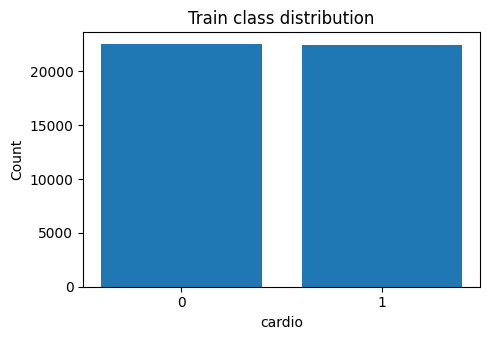

Insight: ratio cardio=1 trên train ≈ 0.4997 → gần 50/50, KHÔNG cần SMOTE/oversampling.


In [14]:
class_balance = y_train.value_counts().sort_index().reset_index()
class_balance.columns = [TARGET, "count"]
class_balance["ratio"] = class_balance["count"] / class_balance["count"].sum()
save_df(class_balance, TABLE_DIR / "05_train_class_balance.csv")
display(class_balance)

plt.figure(figsize=(5, 3.5))
plt.bar(class_balance[TARGET].astype(str), class_balance["count"])
plt.title("Train class distribution")
plt.xlabel("cardio"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_train_class_distribution.png", dpi=160)
plt.show()

print(f"Insight: ratio cardio=1 trên train ≈ {class_balance.loc[class_balance[TARGET]==1, 'ratio'].iloc[0]:.4f} "
      f"→ gần 50/50, KHÔNG cần SMOTE/oversampling.")

### 6.2. Audit y khoa cho dữ liệu raw + bảng tác động cleaning

In [15]:
def raw_medical_audit(X_raw: pd.DataFrame, name: str = "train") -> pd.DataFrame:
    age = pd.to_numeric(X_raw["age"], errors="coerce")
    height = pd.to_numeric(X_raw["height"], errors="coerce")
    weight = pd.to_numeric(X_raw["weight"], errors="coerce")
    ap_hi = pd.to_numeric(X_raw["ap_hi"], errors="coerce")
    ap_lo = pd.to_numeric(X_raw["ap_lo"], errors="coerce")
    checks = [
        ("age_raw_gt_1000_probably_days", age > 1000),
        (f"height_outside_{CONFIG['height_range_cm'][0]}_{CONFIG['height_range_cm'][1]}",
         ~height.between(*CONFIG["height_range_cm"])),
        (f"weight_outside_{CONFIG['weight_range_kg'][0]}_{CONFIG['weight_range_kg'][1]}",
         ~weight.between(*CONFIG["weight_range_kg"])),
        (f"ap_hi_outside_{CONFIG['ap_hi_range'][0]}_{CONFIG['ap_hi_range'][1]}",
         ~ap_hi.between(*CONFIG["ap_hi_range"])),
        (f"ap_lo_outside_{CONFIG['ap_lo_range'][0]}_{CONFIG['ap_lo_range'][1]}",
         ~ap_lo.between(*CONFIG["ap_lo_range"])),
        ("ap_lo_ge_ap_hi", ap_lo >= ap_hi),
        ("cholesterol_not_1_2_3",
         ~pd.to_numeric(X_raw["cholesterol"], errors="coerce").isin([1, 2, 3])),
        ("gluc_not_1_2_3",
         ~pd.to_numeric(X_raw["gluc"], errors="coerce").isin([1, 2, 3])),
    ]
    rows = []
    for check_name, mask in checks:
        mask = pd.Series(mask).fillna(True)
        rows.append({"split": name, "check": check_name,
                     "n_invalid": int(mask.sum()), "rate": float(mask.mean())})
    return pd.DataFrame(rows)


train_raw_audit = raw_medical_audit(X_train, "train")
save_df(train_raw_audit, TABLE_DIR / "05_train_raw_medical_audit.csv")
display(train_raw_audit)

,split,check,n_invalid,rate
0,train,age_raw_gt_1000_probably_days,44999,1.000000
1,train,height_outside_130.0_220.0,65,0.001444
2,train,weight_outside_30.0_180.0,7,0.000156
3,train,ap_hi_outside_80.0_250.0,154,0.003422
4,train,ap_lo_outside_40.0_180.0,640,0.014223
5,train,ap_lo_ge_ap_hi,774,0.017200
6,train,cholesterol_not_1_2_3,0,0.000000
7,train,gluc_not_1_2_3,0,0.000000


In [16]:
def build_cleaning_impact_table(X_fe: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    rules = [
        ("age outside plausible range",   "age_invalid_flag",         "age_years"),
        ("height outside clinical range", "height_invalid_flag",      "height_clean"),
        ("weight outside clinical range", "weight_invalid_flag",      "weight_clean"),
        ("blood pressure invalid",        "bp_invalid_flag",          "ap_hi_clean"),
        ("ap_lo >= ap_hi",                "bp_order_invalid_flag",    "ap_hi_clean"),
        ("BMI outside plausible range",   "bmi_invalid_flag",         "bmi"),
        ("cholesterol outside 1/2/3",     "cholesterol_invalid_flag", "cholesterol"),
        ("gluc outside 1/2/3",            "gluc_invalid_flag",        "gluc"),
    ]
    rows = []
    y = pd.Series(y).reset_index(drop=True)
    X_fe = X_fe.reset_index(drop=True)
    for rule, flag_col, cleaned_col in rules:
        mask = X_fe[flag_col].fillna(0).astype(int).astype(bool)
        rows.append({
            "rule": rule, "flag_column": flag_col, "cleaned_column": cleaned_col,
            "n_affected": int(mask.sum()),
            "rate_affected": float(mask.mean()),
            "n_missing_after_cleaning": int(X_fe[cleaned_col].isna().sum()),
            "cardio_rate_affected":   float(y[mask].mean())  if mask.any()  else np.nan,
            "cardio_rate_unaffected": float(y[~mask].mean()) if (~mask).any() else np.nan,
        })
    return pd.DataFrame(rows)


cleaning_impact = build_cleaning_impact_table(train_fe_preview, y_train)
save_df(cleaning_impact, TABLE_DIR / "05_cleaning_impact_per_rule.csv")
display(cleaning_impact)

# Insight inline
top_impact = cleaning_impact.nlargest(3, "n_affected")
print("Insight: 3 rule ảnh hưởng nhiều dòng nhất:")
for _, r in top_impact.iterrows():
    print(f"  - {r['rule']}: {r['n_affected']} dòng "
          f"(cardio rate ở nhóm bị ảnh hưởng = {r['cardio_rate_affected']:.3f} "
          f"vs nhóm bình thường = {r['cardio_rate_unaffected']:.3f})")

,rule,flag_column,cleaned_column,n_affected,rate_affected,n_missing_after_cleaning,cardio_rate_affected,cardio_rate_unaffected
0,age outside plausible range,age_invalid_flag,age_years,0,0.000000,0,NaN,0.499700
1,height outside clinical range,height_invalid_flag,height_clean,65,0.001444,65,0.492308,0.499711
2,weight outside clinical range,weight_invalid_flag,weight_clean,7,0.000156,7,0.571429,0.499689
3,blood pressure invalid,bp_invalid_flag,ap_hi_clean,840,0.018667,840,0.748810,0.494961
4,ap_lo >= ap_hi,bp_order_invalid_flag,ap_hi_clean,774,0.017200,840,0.773902,0.494901
5,BMI outside plausible range,bmi_invalid_flag,bmi,72,0.001600,72,0.500000,0.499700
6,cholesterol outside 1/2/3,cholesterol_invalid_flag,cholesterol,0,0.000000,0,NaN,0.499700
7,gluc outside 1/2/3,gluc_invalid_flag,gluc,0,0.000000,0,NaN,0.499700


Insight: 3 rule ảnh hưởng nhiều dòng nhất:
  - blood pressure invalid: 840 dòng (cardio rate ở nhóm bị ảnh hưởng = 0.749 vs nhóm bình thường = 0.495)
  - ap_lo >= ap_hi: 774 dòng (cardio rate ở nhóm bị ảnh hưởng = 0.774 vs nhóm bình thường = 0.495)
  - BMI outside plausible range: 72 dòng (cardio rate ở nhóm bị ảnh hưởng = 0.500 vs nhóm bình thường = 0.500)


### 6.3. IQR audit (mô tả, không lọc dữ liệu)

In [17]:
def iqr_outlier_audit(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        s = pd.to_numeric(df[col], errors="coerce")
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (s < lower) | (s > upper)
        rows.append({
            "feature": col, "q1": float(q1), "q3": float(q3), "iqr": float(iqr),
            "lower_fence_descriptive_only": float(lower),
            "upper_fence_descriptive_only": float(upper),
            "n_iqr_outliers_descriptive_only": int(mask.fillna(False).sum()),
            "outlier_rate_descriptive_only": float(mask.fillna(False).mean()),
            "used_for_filtering": False,
        })
    return pd.DataFrame(rows)


iqr_audit_train = iqr_outlier_audit(
    X_train, ["age", "height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc"]
)
save_df(iqr_audit_train, TABLE_DIR / "05_train_iqr_outlier_audit_descriptive.csv")
display(iqr_audit_train)
print("LƯU Ý: IQR fence là descriptive_only — KHÔNG dùng để lọc dữ liệu "
      "(tính trên toàn train có thể leakage tinh vi nếu lan sang val/test).")

,feature,q1,q3,iqr,lower_fence_descriptive_only,upper_fence_descriptive_only,n_iqr_outliers_descriptive_only,outlier_rate_descriptive_only,used_for_filtering
0,age,17666.5,21320.0,3653.5,12186.25,26800.25,3,0.000067,False
1,height,159.0,170.0,11.0,142.50,186.50,358,0.007956,False
2,weight,65.0,82.0,17.0,39.50,107.50,1179,0.026201,False
3,ap_hi,120.0,140.0,20.0,90.00,170.00,905,0.020112,False
4,ap_lo,80.0,90.0,10.0,65.00,105.00,2993,0.066513,False
5,cholesterol,1.0,2.0,1.0,-0.50,3.50,0,0.000000,False
6,gluc,1.0,1.0,0.0,1.00,1.00,6719,0.149314,False


LƯU Ý: IQR fence là descriptive_only — KHÔNG dùng để lọc dữ liệu (tính trên toàn train có thể leakage tinh vi nếu lan sang val/test).


### 6.4. Phân phối numeric theo cardio

In [18]:
# EDA dataframe: FIT và TRANSFORM hoàn toàn trên TRAIN để tránh EDA leakage.
# Không dùng X_all / validation / test ở bất kỳ bảng hoặc biểu đồ EDA nào bên dưới.
eda_fe_for_audit = make_feature_engineer_from_config(CONFIG)
eda_df = eda_fe_for_audit.fit_transform(X_train)
assert list(eda_df.columns) == FE_OUTPUT_FEATURES
assert len(eda_df) == len(y_train) == len(X_train)
assert set(eda_df.index) == set(range(len(X_train)))
eda_df = add_medical_level_labels(eda_df, columns=("cholesterol", "gluc"))
eda_df[TARGET] = y_train.reset_index(drop=True).values

eda_train_only_audit = {
    "status": "PASS",
    "eda_scope": "train_only",
    "fit_data": "X_train only",
    "transform_data": "X_train only",
    "n_rows_eda": int(len(eda_df)),
    "n_rows_train": int(len(X_train)),
    "n_rows_val_cal": int(len(X_val_cal)),
    "n_rows_val_select": int(len(X_val_select)),
    "n_rows_val_threshold": int(len(X_val_threshold)),
    "n_rows_test": int(len(X_test)),
    "age_median_seen_train_only": float(eda_fe_for_audit.age_median_seen_),
    "age_is_days_train_only": bool(eda_fe_for_audit.age_is_days_),
    "leakage_note": "EDA tables/figures below are computed after split and only on train set.",
}
save_json(eda_train_only_audit, TABLE_DIR / "05_eda_train_only_audit.json")
print("EDA train-only audit: PASS")
print(json.dumps(eda_train_only_audit, indent=2, ensure_ascii=False))

summary_cols = ["age_years", "bmi", "ap_hi_clean", "ap_lo_clean",
                "pulse_pressure", "map_proxy", "cholesterol", "gluc"]
eda_summary_by_target = (
    eda_df.groupby(TARGET)[summary_cols]
    .agg(["count", "mean", "std", "median", "min", "max"]).round(3)
)
save_df(eda_summary_by_target.reset_index(), TABLE_DIR / "05_train_numeric_summary_by_target.csv")
display(eda_summary_by_target)

ordinal_distribution_rows = []
for col in ["cholesterol", "gluc"]:
    vc = eda_df[col].value_counts(dropna=False).sort_index()
    for level, count in vc.items():
        ordinal_distribution_rows.append({
            "feature": col,
            "level_code": level,
            "level_label": medical_level_label(col, level),
            "clinical_cutoff_reference": clinical_cutoff_label(col, level),
            "count": int(count),
            "ratio": float(count / len(eda_df)),
        })
ordinal_distribution = pd.DataFrame(ordinal_distribution_rows)
save_df(ordinal_distribution, TABLE_DIR / "05_ordinal_chol_gluc_distribution_train.csv")
display(ordinal_distribution)


EDA train-only audit: PASS
{
  "status": "PASS",
  "eda_scope": "train_only",
  "fit_data": "X_train only",
  "transform_data": "X_train only",
  "n_rows_eda": 44999,
  "n_rows_train": 44999,
  "n_rows_val_cal": 5001,
  "n_rows_val_select": 4998,
  "n_rows_val_threshold": 5002,
  "n_rows_test": 10000,
  "age_median_seen_train_only": 19701.0,
  "age_is_days_train_only": true,
  "leakage_note": "EDA tables/figures below are computed after split and only on train set."
}


age_years                                           bmi                 \
           count    mean    std  median     min     max  count    mean    std   
cardio                                                                          
0          22513  51.694  6.759  52.027  29.563  64.827  22477  26.457  4.758   
1          22486  54.907  6.337  55.814  39.083  64.865  22450  28.504  5.446   

                ... cholesterol                  gluc                       \
        median  ...         std median min max  count   mean    std median   
cardio          ...                                                          
0       25.462  ...       0.527    1.0   1   3  22513  1.174  0.509    1.0   
1       27.471  ...       0.780    1.0   1   3  22486  1.277  0.625    1.0   

                
       min max  
cardio          
0        1   3  
1        1   3  

[2 rows x 48 columns]

,feature,level_code,level_label,clinical_cutoff_reference,count,ratio
0,cholesterol,1,1 = bình thường,< 200 mg/dL,33642,0.747617
1,cholesterol,2,2 = cao hơn bình thường,200–239 mg/dL,6099,0.135536
2,cholesterol,3,3 = rất cao,≥ 240 mg/dL,5258,0.116847
3,gluc,1,1 = bình thường,≤ 99 mg/dL,38280,0.850686
4,gluc,2,2 = cao hơn bình thường,100–125 mg/dL,3287,0.073046
5,gluc,3,3 = rất cao,≥ 126 mg/dL,3432,0.076268


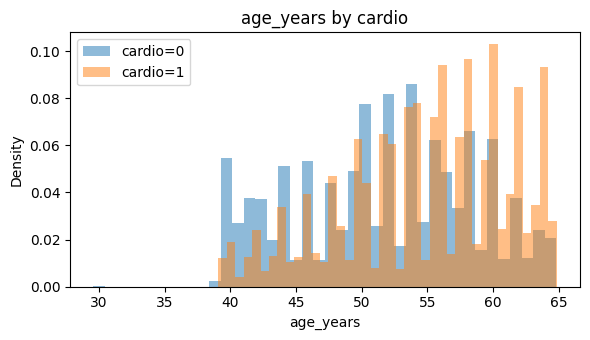

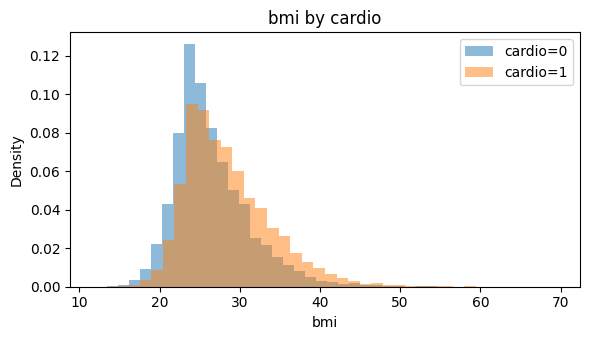

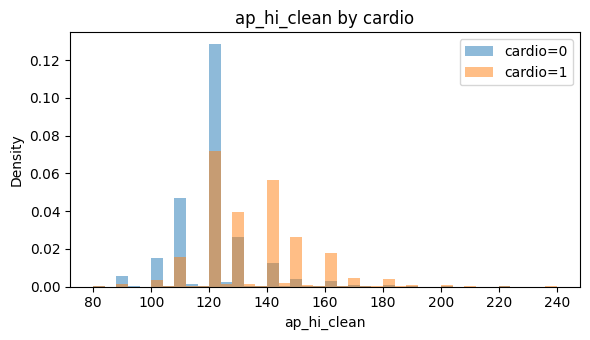

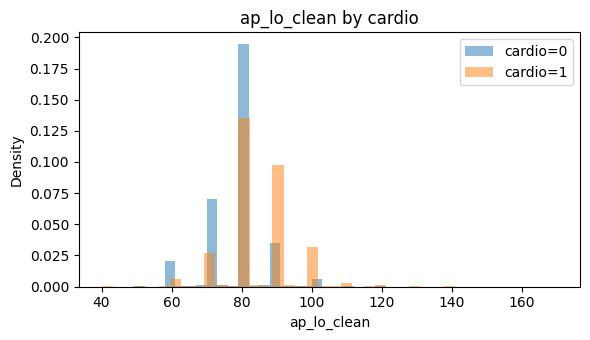

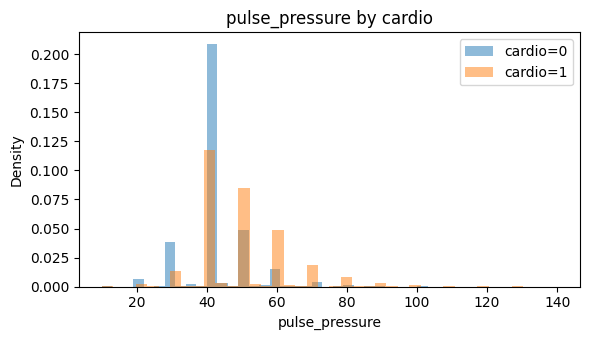

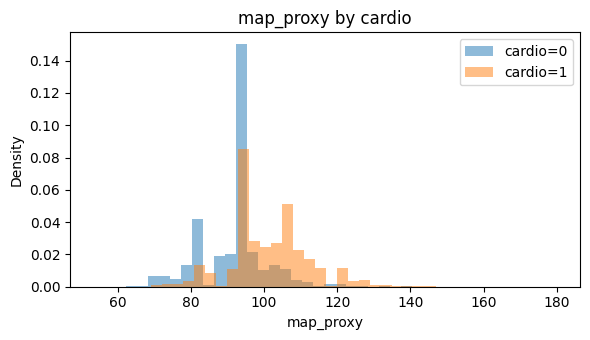

In [19]:
# Histogram density overlay theo cardio
important_vars = ["age_years", "bmi", "ap_hi_clean", "ap_lo_clean",
                  "pulse_pressure", "map_proxy"]
for col in important_vars:
    plt.figure(figsize=(6, 3.5))
    for tv in [0, 1]:
        values = eda_df.loc[eda_df[TARGET] == tv, col].dropna()
        plt.hist(values, bins=40, alpha=0.5, density=True, label=f"cardio={tv}")
    plt.title(f"{col} by cardio")
    plt.xlabel(col); plt.ylabel("Density"); plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"05_hist_{col}_by_cardio.png", dpi=160)
    plt.show()

/tmp/ipykernel_24/156016835.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([data0, data1], labels=["cardio=0", "cardio=1"], showfliers=False)


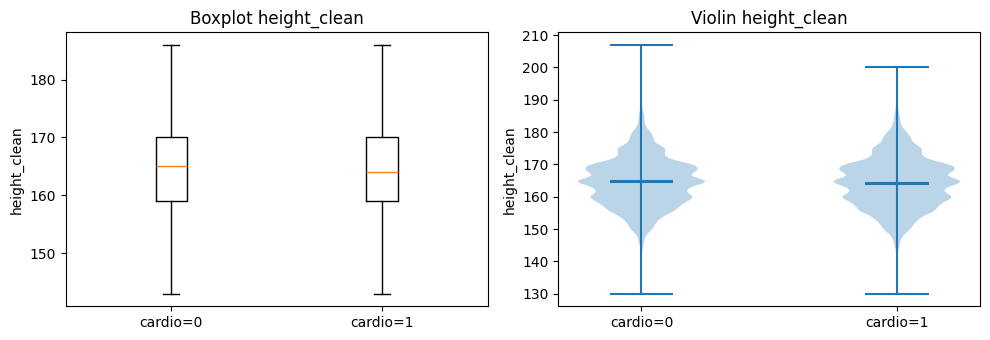

/tmp/ipykernel_24/156016835.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([data0, data1], labels=["cardio=0", "cardio=1"], showfliers=False)


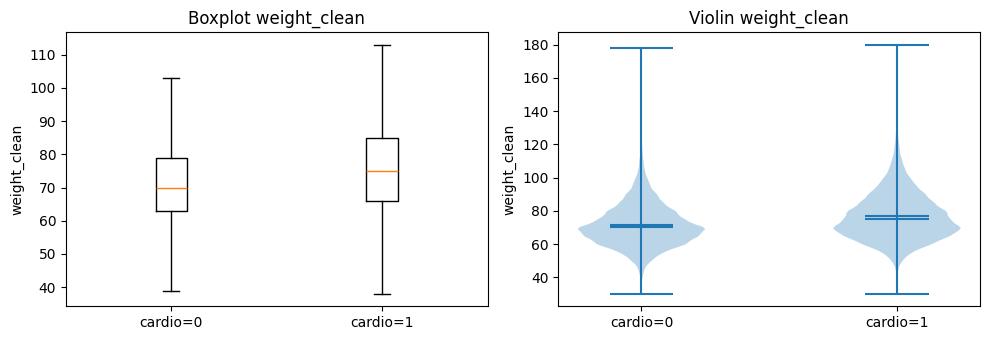

/tmp/ipykernel_24/156016835.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([data0, data1], labels=["cardio=0", "cardio=1"], showfliers=False)


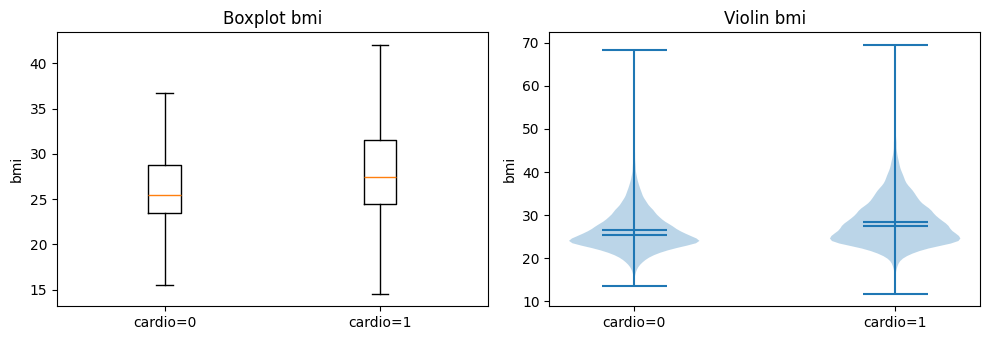

/tmp/ipykernel_24/156016835.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([data0, data1], labels=["cardio=0", "cardio=1"], showfliers=False)


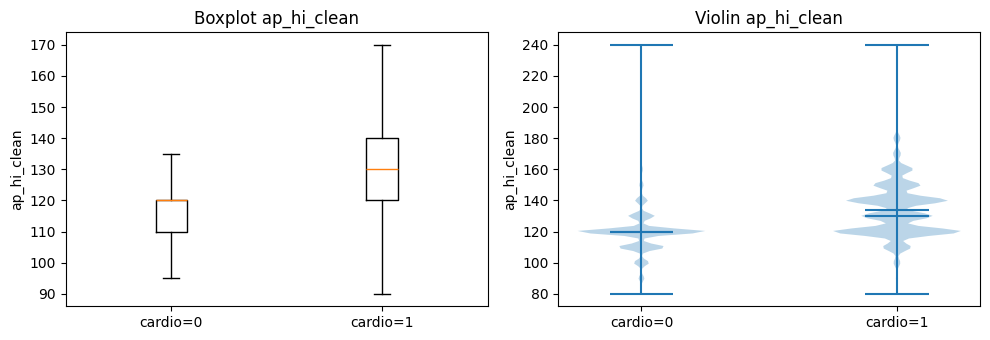

/tmp/ipykernel_24/156016835.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([data0, data1], labels=["cardio=0", "cardio=1"], showfliers=False)


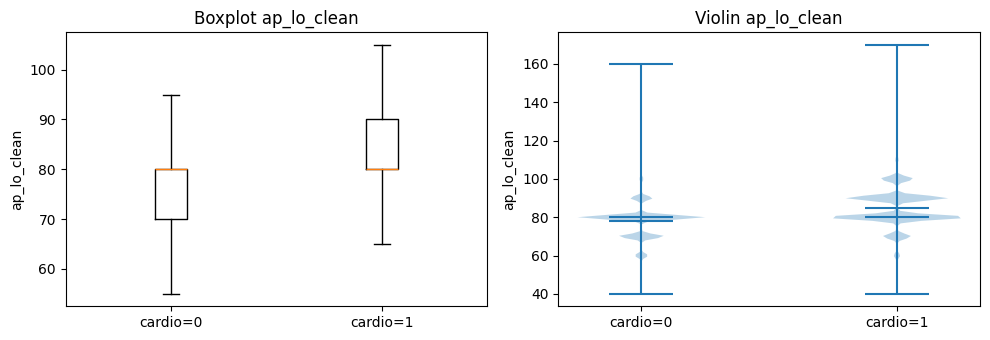

/tmp/ipykernel_24/156016835.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([data0, data1], labels=["cardio=0", "cardio=1"], showfliers=False)


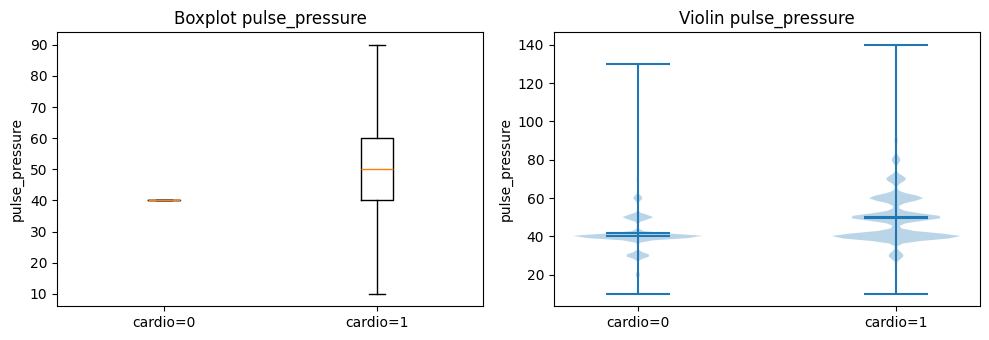

/tmp/ipykernel_24/156016835.py:18: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(X_train["height"].dropna(), vert=True, showfliers=True)
/tmp/ipykernel_24/156016835.py:21: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(X_train["weight"].dropna(), vert=True, showfliers=True)


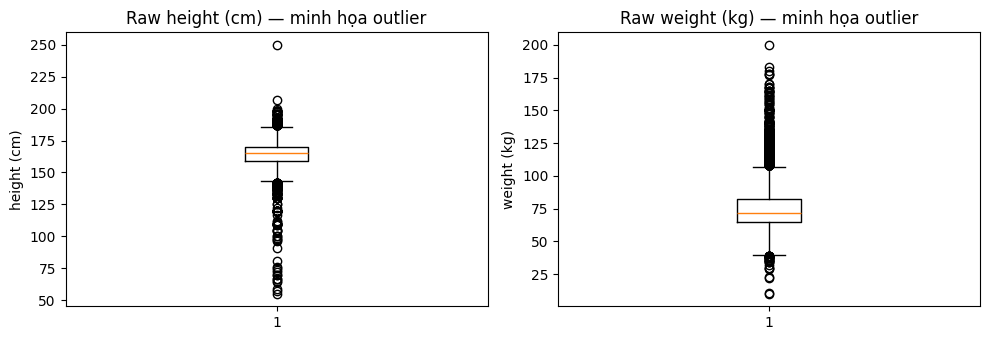

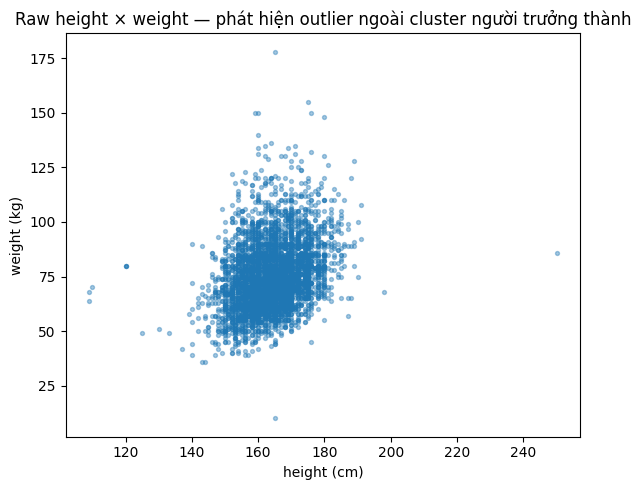

In [20]:
# Boxplot + violin-like overlay
for col in ["height_clean", "weight_clean", "bmi",
            "ap_hi_clean", "ap_lo_clean", "pulse_pressure"]:
    data0 = eda_df.loc[eda_df[TARGET] == 0, col].dropna()
    data1 = eda_df.loc[eda_df[TARGET] == 1, col].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].boxplot([data0, data1], labels=["cardio=0", "cardio=1"], showfliers=False)
    axes[0].set_title(f"Boxplot {col}"); axes[0].set_ylabel(col)
    parts = axes[1].violinplot([data0, data1], showmeans=True, showmedians=True)
    axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(["cardio=0", "cardio=1"])
    axes[1].set_title(f"Violin {col}"); axes[1].set_ylabel(col)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"05_box_violin_{col}_by_cardio.png", dpi=160)
    plt.show()

# Boxplot raw height/weight để minh họa outlier dataset
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].boxplot(X_train["height"].dropna(), vert=True, showfliers=True)
axes[0].set_title("Raw height (cm) — minh họa outlier")
axes[0].set_ylabel("height (cm)")
axes[1].boxplot(X_train["weight"].dropna(), vert=True, showfliers=True)
axes[1].set_title("Raw weight (kg) — minh họa outlier")
axes[1].set_ylabel("weight (kg)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_boxplot_raw_height_weight_outliers.png", dpi=160)
plt.show()

# Scatter raw height x weight
plt.figure(figsize=(6, 5))
sample = X_train.sample(n=min(5000, len(X_train)), random_state=SEED)
plt.scatter(sample["height"], sample["weight"], s=8, alpha=0.4)
plt.xlabel("height (cm)"); plt.ylabel("weight (kg)")
plt.title("Raw height × weight — phát hiện outlier ngoài cluster người trưởng thành")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_scatter_raw_height_weight.png", dpi=160)
plt.show()

### 6.4b. Raw vs cleaned blood pressure audit


,feature,count,mean,std,min,median,max
0,ap_hi_raw,44999.0,128.856308,155.201034,-150.0,120.0,16020.0
1,ap_lo_raw,44999.0,96.677259,197.842788,-70.0,80.0,11000.0
2,ap_hi_clean,44159.0,126.740732,16.753219,80.0,120.0,240.0
3,ap_lo_clean,44159.0,81.328767,9.477302,40.0,80.0,170.0
4,bp_invalid_flag,44999.0,0.018667,0.135348,0.0,0.0,1.0
5,bp_order_invalid_flag,44999.0,0.017200,0.130019,0.0,0.0,1.0
6,cardio,44999.0,0.499700,0.500005,0.0,0.0,1.0


,ap_hi_raw,ap_lo_raw,ap_hi_clean,ap_lo_clean,bp_invalid_flag,bp_order_invalid_flag,cardio,abs_ap_hi,abs_ap_lo
26338,16020,80,NaN,NaN,1,0,1,16020,80
30207,14020,90,NaN,NaN,1,0,1,14020,90
16463,14020,80,NaN,NaN,1,0,1,14020,80
35888,13010,80,NaN,NaN,1,0,0,13010,80
5028,11500,90,NaN,NaN,1,0,1,11500,90
33089,11020,80,NaN,NaN,1,0,1,11020,80
8930,1500,80,NaN,NaN,1,0,1,1500,80
5764,1420,80,NaN,NaN,1,0,1,1420,80
27877,1420,80,NaN,NaN,1,0,1,1420,80
32711,1409,90,NaN,NaN,1,0,1,1409,90


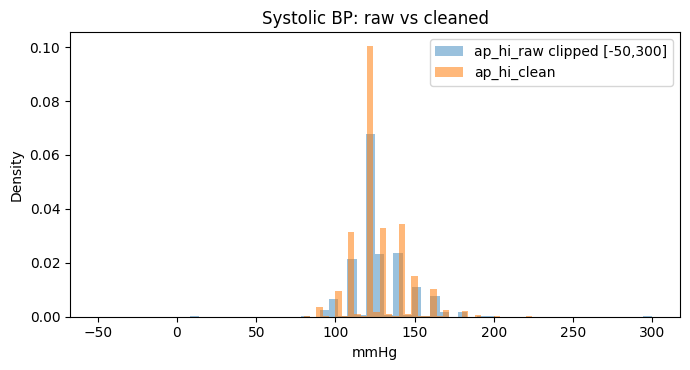

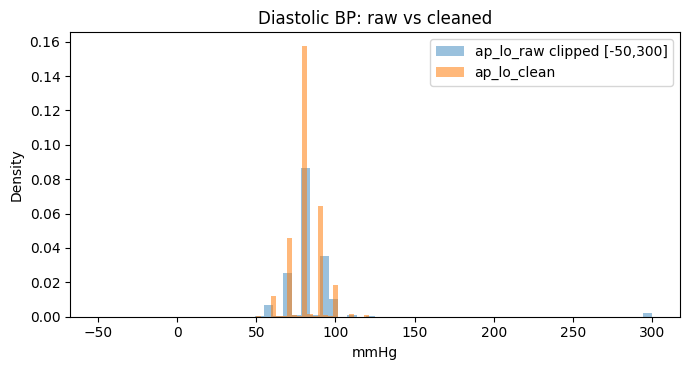

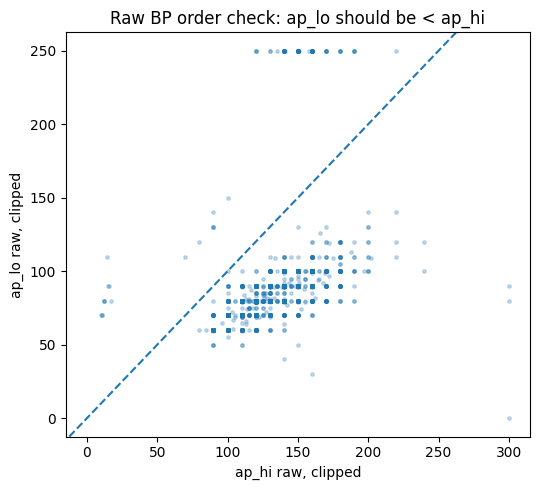

In [21]:
# Raw vs cleaned blood pressure visualization
bp_raw_clean = pd.DataFrame({
    "ap_hi_raw": pd.to_numeric(X_train["ap_hi"], errors="coerce"),
    "ap_lo_raw": pd.to_numeric(X_train["ap_lo"], errors="coerce"),
    "ap_hi_clean": pd.to_numeric(eda_df["ap_hi_clean"], errors="coerce"),
    "ap_lo_clean": pd.to_numeric(eda_df["ap_lo_clean"], errors="coerce"),
    "bp_invalid_flag": eda_df.get("bp_invalid_flag", pd.Series(index=eda_df.index, dtype=float)),
    "bp_order_invalid_flag": eda_df.get("bp_order_invalid_flag", pd.Series(index=eda_df.index, dtype=float)),
    TARGET: y_train.values,
})
bp_summary = bp_raw_clean.agg(["count", "mean", "std", "min", "median", "max"]).T.reset_index()
bp_summary = bp_summary.rename(columns={"index": "feature"})
save_df(bp_summary, TABLE_DIR / "05b_raw_vs_clean_bp_summary.csv")
display(bp_summary)

# Lưu một vài ca raw bất thường để trình bày khi bảo vệ.
bp_extreme_examples = (
    bp_raw_clean[
        (bp_raw_clean["ap_hi_raw"] < CONFIG["ap_hi_range"][0]) |
        (bp_raw_clean["ap_hi_raw"] > CONFIG["ap_hi_range"][1]) |
        (bp_raw_clean["ap_lo_raw"] < CONFIG["ap_lo_range"][0]) |
        (bp_raw_clean["ap_lo_raw"] > CONFIG["ap_lo_range"][1]) |
        (bp_raw_clean["ap_lo_raw"] >= bp_raw_clean["ap_hi_raw"])
    ]
    .assign(abs_ap_hi=lambda d: d["ap_hi_raw"].abs(),
            abs_ap_lo=lambda d: d["ap_lo_raw"].abs())
    .sort_values(["abs_ap_hi", "abs_ap_lo"], ascending=False)
    .head(25)
)
save_df(bp_extreme_examples, TABLE_DIR / "05b_bp_extreme_examples_train.csv")
display(bp_extreme_examples.head(10))

# Histogram raw bị giới hạn trục để thấy vùng y khoa; outlier cực lớn được audit trong bảng phía trên.
for raw_col, clean_col, title in [
    ("ap_hi_raw", "ap_hi_clean", "Systolic BP: raw vs cleaned"),
    ("ap_lo_raw", "ap_lo_clean", "Diastolic BP: raw vs cleaned"),
]:
    plt.figure(figsize=(7, 3.8))
    plt.hist(bp_raw_clean[raw_col].dropna().clip(-50, 300), bins=60, alpha=0.45, density=True, label=f"{raw_col} clipped [-50,300]")
    plt.hist(bp_raw_clean[clean_col].dropna(), bins=40, alpha=0.55, density=True, label=clean_col)
    plt.xlabel("mmHg")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"05b_{clean_col}_raw_vs_clean.png", dpi=160)
    plt.show()

plt.figure(figsize=(5.5, 5))
valid_plot = bp_raw_clean.sample(n=min(5000, len(bp_raw_clean)), random_state=SEED)
plt.scatter(valid_plot["ap_hi_raw"].clip(-50, 300), valid_plot["ap_lo_raw"].clip(-50, 250),
            s=6, alpha=0.25)
plt.axline((0, 0), slope=1, linestyle="--")
plt.xlabel("ap_hi raw, clipped")
plt.ylabel("ap_lo raw, clipped")
plt.title("Raw BP order check: ap_lo should be < ap_hi")
plt.tight_layout()
plt.savefig(FIG_DIR / "05b_raw_bp_order_scatter.png", dpi=160)
plt.show()


### 6.5. Risk rate theo nhóm + insight inline

Riêng `cholesterol` và `gluc` được trình bày theo **code ordinal gốc** và **nhãn rõ nghĩa** theo data dictionary:

| Feature | Code 1 | Code 2 | Code 3 |
|---|---|---|---|
| `cholesterol` | bình thường | cao hơn bình thường | rất cao |
| `gluc` | bình thường | cao hơn bình thường | rất cao |

**Lưu ý học thuật quan trọng:** dataset chỉ cung cấp mã ordinal 1/2/3, **không cung cấp giá trị xét nghiệm gốc theo mg/dL**. Các ngưỡng y khoa như cholesterol `<200`, `200–239`, `≥240 mg/dL` hoặc fasting glucose `≤99`, `100–125`, `≥126 mg/dL` chỉ là **tham khảo diễn giải**, không được xem là mapping đo lường trực tiếp của từng bệnh nhân.


In [22]:
risk_features = ["gender", "age_group", "bmi_group", "bp_stage",
                 "cholesterol", "gluc", "smoke", "alco", "active"]
risk_tables = []
feature_order_map = {feature: i for i, feature in enumerate(risk_features)}

for col in risk_features:
    tmp = (
        eda_df.groupby(col, dropna=False)[TARGET]
        .agg(n="size", cardio_rate="mean")
        .reset_index()
        .rename(columns={col: "level"})
    )
    tmp.insert(0, "feature", col)
    tmp["feature_order"] = feature_order_map[col]

    if col in ORDINAL_MEDICAL_LEVELS:
        tmp["level_code"] = pd.to_numeric(tmp["level"], errors="coerce").astype("Int64")
        tmp["level_label"] = tmp["level"].map(lambda v: medical_level_label(col, v))
        tmp["sort_order"] = pd.to_numeric(tmp["level"], errors="coerce").fillna(999).astype(float)
    else:
        tmp["level_code"] = pd.NA
        tmp["level_label"] = tmp["level"].astype(str)
        # Numeric/binary sort trước; categorical fallback sort theo chữ.
        numeric_order = pd.to_numeric(tmp["level"], errors="coerce")
        fallback_order = pd.Series(np.arange(len(tmp)) + 100, index=tmp.index, dtype=float)
        tmp["sort_order"] = numeric_order.where(numeric_order.notna(), fallback_order).astype(float)

    risk_tables.append(tmp)

risk_rate_table = (
    pd.concat(risk_tables, ignore_index=True)
    .sort_values(["feature_order", "sort_order", "level_label"])
    .drop(columns=["feature_order"])
)
save_df(risk_rate_table, TABLE_DIR / "05_train_risk_rate_by_group.csv")
display(risk_rate_table.head(60))

# Bảng nổi bật riêng cho Cholesterol/Glucose: có code, nhãn, số mẫu và tỷ lệ cardio.
chol_gluc_risk_table = risk_rate_table[risk_rate_table["feature"].isin(["cholesterol", "gluc"])][
    ["feature", "level_code", "level_label", "n", "cardio_rate"]
].copy()
chol_gluc_risk_table["clinical_cutoff_reference"] = chol_gluc_risk_table.apply(
    lambda r: clinical_cutoff_label(r["feature"], r["level_code"]), axis=1
)
chol_gluc_risk_table["cardio_rate_pct"] = (100 * chol_gluc_risk_table["cardio_rate"]).round(2)
save_df(chol_gluc_risk_table, TABLE_DIR / "05_cholesterol_glucose_risk_rate_clear_levels.csv")
display(chol_gluc_risk_table)


/tmp/ipykernel_24/3861352206.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(risk_tables, ignore_index=True)


,feature,level,n,cardio_rate,level_code,level_label,sort_order
0,gender,1,29356,0.496832,<NA>,1,1.0
1,gender,2,15643,0.505082,<NA>,2,2.0
2,age_group,40-49,12732,0.380145,<NA>,40-49,100.0
3,age_group,50-59,22885,0.519161,<NA>,50-59,101.0
4,age_group,60-69,8162,0.669689,<NA>,60-69,102.0
5,age_group,<40,1220,0.245082,<NA>,<40,103.0
6,bmi_group,missing,72,0.500000,<NA>,missing,100.0
7,bmi_group,normal,16586,0.399011,<NA>,normal,101.0
8,bmi_group,obese_I,7741,0.606252,<NA>,obese_I,102.0
9,bmi_group,obese_II_plus,4019,0.685743,<NA>,obese_II_plus,103.0


,feature,level_code,level_label,n,cardio_rate,clinical_cutoff_reference,cardio_rate_pct
17,cholesterol,1,1 = bình thường,33642,0.438351,< 200 mg/dL,43.84
18,cholesterol,2,2 = cao hơn bình thường,6099,0.607477,200–239 mg/dL,60.75
19,cholesterol,3,3 = rất cao,5258,0.767212,≥ 240 mg/dL,76.72
20,gluc,1,1 = bình thường,38280,0.480303,≤ 99 mg/dL,48.03
21,gluc,2,2 = cao hơn bình thường,3287,0.598114,100–125 mg/dL,59.81
22,gluc,3,3 = rất cao,3432,0.621795,≥ 126 mg/dL,62.18


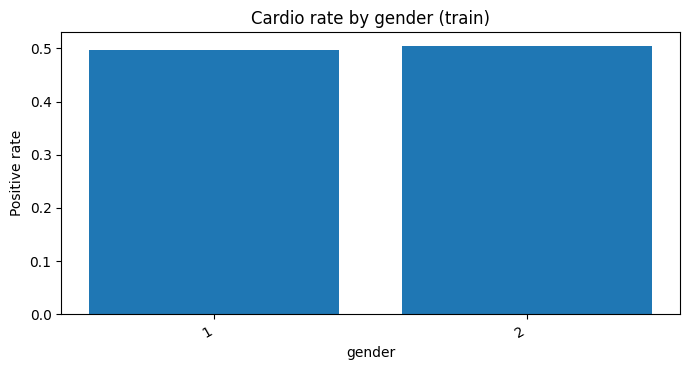

  Insight gender: gap max-min = 0.008; mức cardio cao nhất = 2


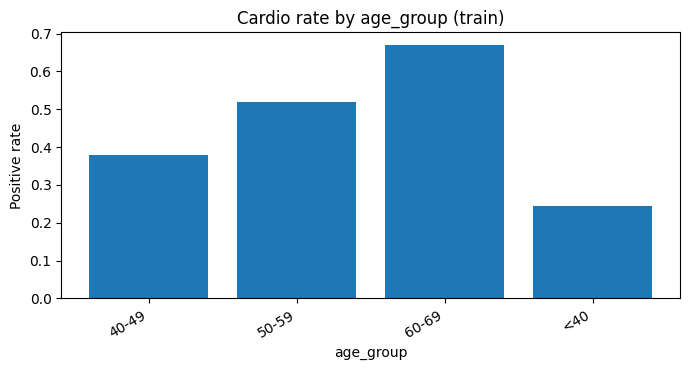

  Insight age_group: gap max-min = 0.425; mức cardio cao nhất = 60-69


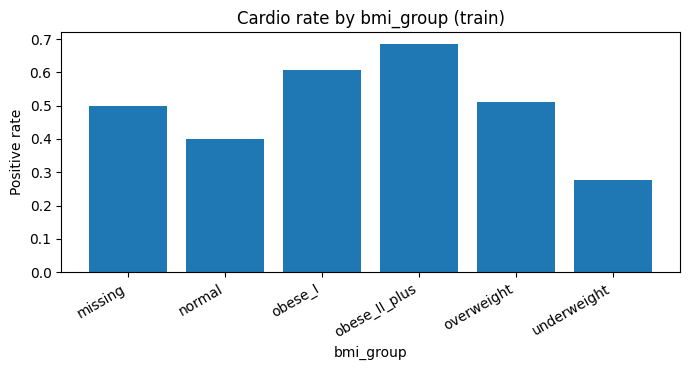

  Insight bmi_group: gap max-min = 0.408; mức cardio cao nhất = obese_II_plus


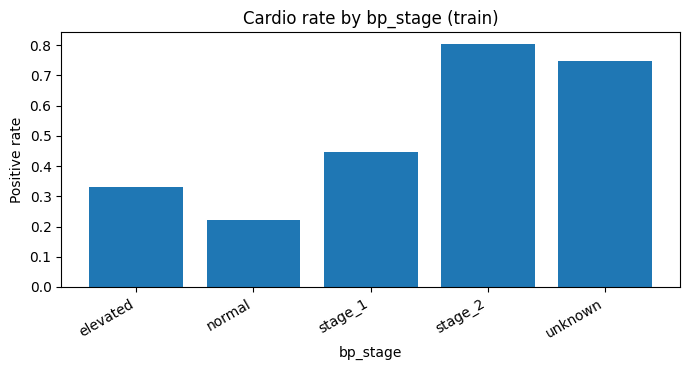

  Insight bp_stage: gap max-min = 0.581; mức cardio cao nhất = stage_2


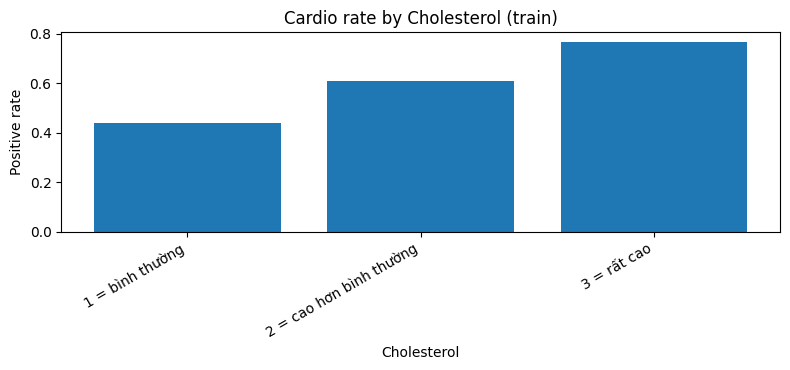

  Insight Cholesterol: gap max-min = 0.329; mức cardio cao nhất = 3 = rất cao


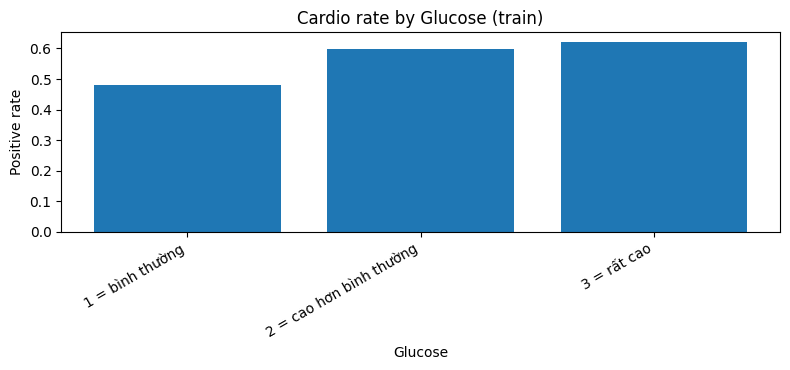

  Insight Glucose: gap max-min = 0.141; mức cardio cao nhất = 3 = rất cao


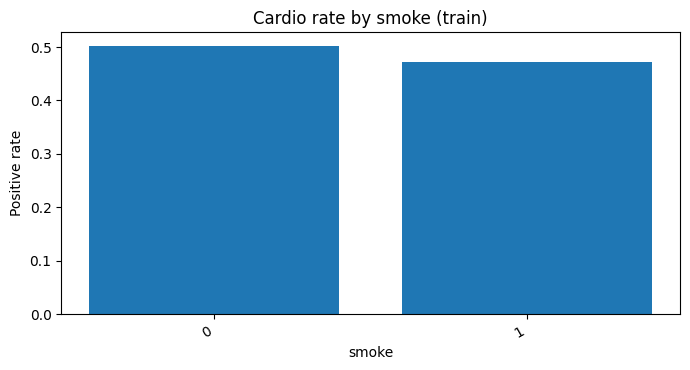

  Insight smoke: gap max-min = 0.030; mức cardio cao nhất = 0


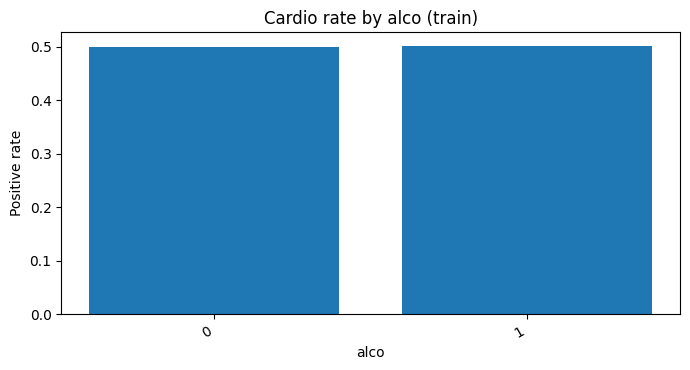

  Insight alco: gap max-min = 0.002; mức cardio cao nhất = 1


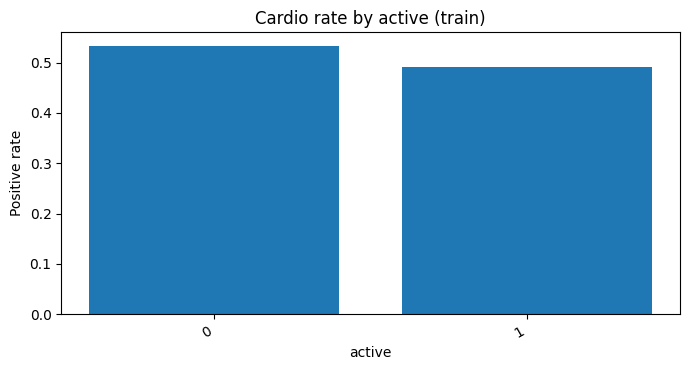

  Insight active: gap max-min = 0.042; mức cardio cao nhất = 0


In [23]:
# Bar plots cho từng risk feature + insight inline
for col in risk_features:
    tmp = risk_rate_table[risk_rate_table["feature"] == col].copy().sort_values("sort_order")
    x_labels = tmp["level_label"].astype(str) if col in ORDINAL_MEDICAL_LEVELS else tmp["level"].astype(str)

    plt.figure(figsize=(8 if col in ORDINAL_MEDICAL_LEVELS else 7, 3.8))
    plt.bar(x_labels, tmp["cardio_rate"])
    display_name = ORDINAL_MEDICAL_DISPLAY_NAME.get(col, col)
    plt.title(f"Cardio rate by {display_name} (train)")
    plt.xlabel(display_name); plt.ylabel("Positive rate")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"05_cardio_rate_by_{col}.png", dpi=160)
    plt.show()

    # Inline insight: gap max-min
    gap = tmp["cardio_rate"].max() - tmp["cardio_rate"].min()
    top_level_label = tmp.loc[tmp["cardio_rate"].idxmax(), "level_label"]
    print(f"  Insight {display_name}: gap max-min = {gap:.3f}; "
          f"mức cardio cao nhất = {top_level_label}")


,age_group,pp_bin,n,cardio_rate
0,40-49,<40,8567,0.249562
1,40-49,40-49,2387,0.571010
2,40-49,50-59,1064,0.746241
3,40-49,60-69,315,0.796825
4,40-49,70+,185,0.848649
5,50-59,<40,13233,0.382680
6,50-59,40-49,5195,0.633109
7,50-59,50-59,2494,0.762630
8,50-59,60-69,906,0.834437
9,50-59,70+,619,0.844911


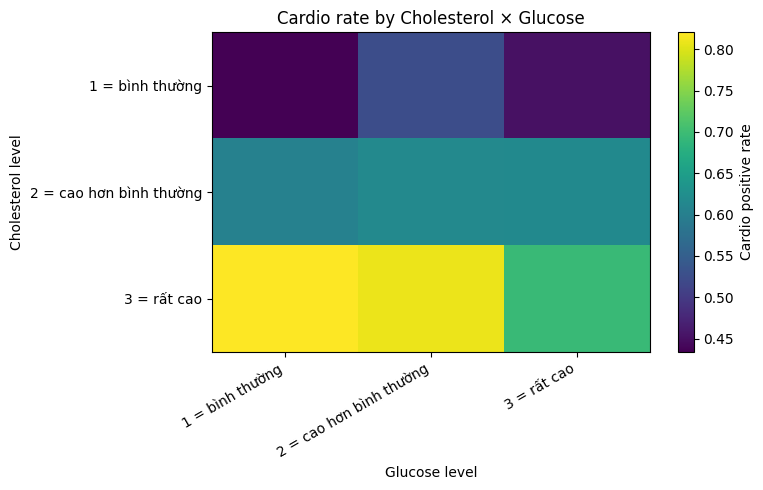

,1 = bình thường,2 = cao hơn bình thường,3 = rất cao
1 = bình thường,0.434046,0.525937,0.451913
2 = cao hơn bình thường,0.604089,0.615236,0.617886
3 = rất cao,0.820379,0.808571,0.696260


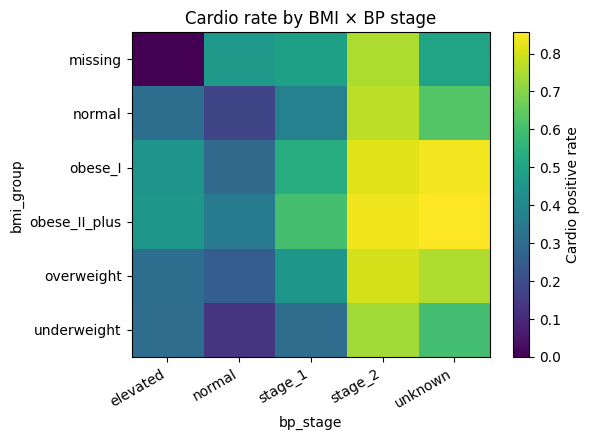

In [24]:
# 3-way: pulse_pressure × age_group → cardio rate
pp_age_table = (
    eda_df.groupby(["age_group", pd.cut(eda_df["pulse_pressure"],
                                         bins=[0, 40, 50, 60, 70, 200],
                                         labels=["<40", "40-49", "50-59", "60-69", "70+"])
                    ], observed=True)[TARGET].agg(n="size", cardio_rate="mean").reset_index()
    .rename(columns={"pulse_pressure": "pp_bin"})
)
save_df(pp_age_table, TABLE_DIR / "05_pp_by_age_group_cardio_rate.csv")
display(pp_age_table.head(20))

# Heatmap cholesterol × gluc với trục có nhãn rõ ràng.
chol_levels = sorted(ORDINAL_MEDICAL_LEVELS["cholesterol"].keys())
gluc_levels = sorted(ORDINAL_MEDICAL_LEVELS["gluc"].keys())
chol_gluc = (
    eda_df.pivot_table(index="cholesterol", columns="gluc", values=TARGET, aggfunc="mean")
    .reindex(index=chol_levels, columns=gluc_levels)
)
chol_gluc_labeled = chol_gluc.copy()
chol_gluc_labeled.index = [medical_level_label("cholesterol", v) for v in chol_gluc_labeled.index]
chol_gluc_labeled.columns = [medical_level_label("gluc", v) for v in chol_gluc_labeled.columns]
save_df(chol_gluc_labeled.reset_index().rename(columns={"index": "cholesterol_level"}),
        TABLE_DIR / "05_cholesterol_gluc_cardio_heatmap_labeled.csv")

plt.figure(figsize=(7.8, 5.0))
plt.imshow(chol_gluc, aspect="auto")
plt.colorbar(label="Cardio positive rate")
plt.xticks(range(len(chol_gluc.columns)),
           [medical_level_label("gluc", c) for c in chol_gluc.columns],
           rotation=30, ha="right")
plt.yticks(range(len(chol_gluc.index)),
           [medical_level_label("cholesterol", r) for r in chol_gluc.index])
plt.xlabel("Glucose level"); plt.ylabel("Cholesterol level")
plt.title("Cardio rate by Cholesterol × Glucose")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_heatmap_cholesterol_gluc.png", dpi=160)
plt.show()

display(chol_gluc_labeled)

# BMI x BP stage heatmap
bmi_bp = eda_df.pivot_table(index="bmi_group", columns="bp_stage",
                              values=TARGET, aggfunc="mean")
save_df(bmi_bp.reset_index(), TABLE_DIR / "05_bmi_bp_cardio_heatmap.csv")
plt.figure(figsize=(6, 4.5))
plt.imshow(bmi_bp, aspect="auto")
plt.colorbar(label="Cardio positive rate")
plt.xticks(range(len(bmi_bp.columns)), bmi_bp.columns, rotation=30, ha="right")
plt.yticks(range(len(bmi_bp.index)), bmi_bp.index)
plt.xlabel("bp_stage"); plt.ylabel("bmi_group")
plt.title("Cardio rate by BMI × BP stage")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_heatmap_bmi_bp.png", dpi=160)
plt.show()


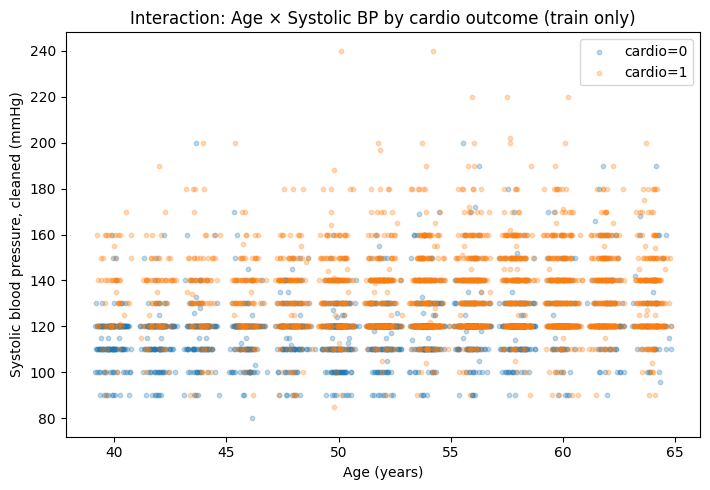

In [25]:
# Interaction plot: age_years × ap_hi_clean theo cardio (train only).
interaction_sample_n = min(CONFIG.get("interaction_scatter_sample", 5000), len(eda_df))
interaction_sample = eda_df.sample(n=interaction_sample_n, random_state=SEED).dropna(
    subset=["age_years", "ap_hi_clean", TARGET]
)
plt.figure(figsize=(7.2, 5.0))
for tv, label in [(0, "cardio=0"), (1, "cardio=1")]:
    mask = interaction_sample[TARGET] == tv
    plt.scatter(interaction_sample.loc[mask, "age_years"],
                interaction_sample.loc[mask, "ap_hi_clean"],
                s=10, alpha=0.28, label=label)
plt.xlabel("Age (years)")
plt.ylabel("Systolic blood pressure, cleaned (mmHg)")
plt.title("Interaction: Age × Systolic BP by cardio outcome (train only)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_scatter_age_vs_aphi_by_cardio.png", dpi=160)
plt.show()
save_json({
    "status": "saved",
    "scope": "train_only",
    "figure": "figures/05_scatter_age_vs_aphi_by_cardio.png",
    "n_points_plotted": int(len(interaction_sample)),
    "note": "Visualization only; not used for model/threshold/calibrator selection.",
}, TABLE_DIR / "05_scatter_age_vs_aphi_by_cardio_audit.json")


### 6.6. Correlation + VIF

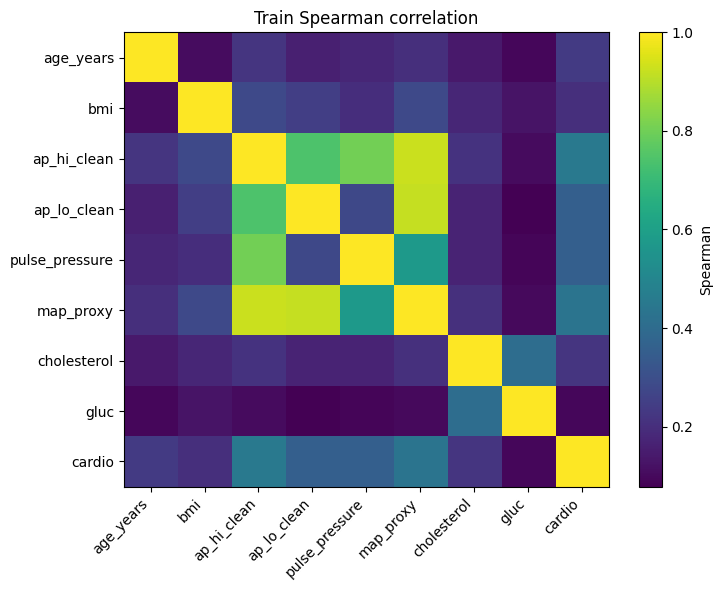

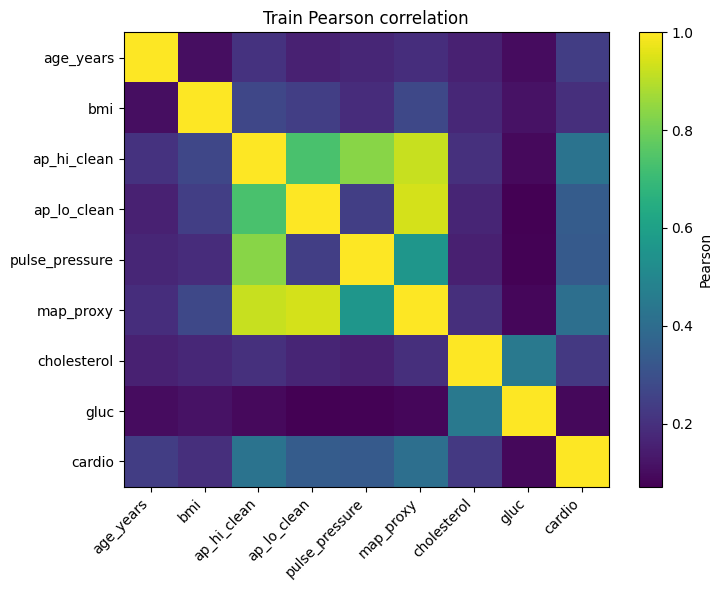

,feature,pearson_with_target,spearman_with_target,abs_pearson,abs_spearman
2,ap_hi_clean,0.426371,0.452415,0.426371,0.452415
5,map_proxy,0.408818,0.433518,0.408818,0.433518
4,pulse_pressure,0.334254,0.357700,0.334254,0.357700
3,ap_lo_clean,0.340617,0.357366,0.340617,0.357366
0,age_years,0.238109,0.234653,0.238109,0.234653
6,cholesterol,0.225813,0.220502,0.225813,0.220502
1,bmi,0.196335,0.202973,0.196335,0.202973
7,gluc,0.090248,0.093033,0.090248,0.093033


Top |corr_spearman| với target:
ap_hi_clean       0.452415
map_proxy         0.433518
pulse_pressure    0.357700
ap_lo_clean       0.357366
age_years         0.234653
cholesterol       0.220502
bmi               0.202973
gluc              0.093033
Name: cardio, dtype: float64


In [26]:
corr_features = ["age_years", "bmi", "ap_hi_clean", "ap_lo_clean",
                 "pulse_pressure", "map_proxy", "cholesterol", "gluc", TARGET]

corr_spearman = eda_df[corr_features].corr(method="spearman")
save_df(corr_spearman.reset_index().rename(columns={"index": "feature"}),
        TABLE_DIR / "05_train_spearman_correlation.csv")
plt.figure(figsize=(7.5, 6))
plt.imshow(corr_spearman, aspect="auto")
plt.colorbar(label="Spearman")
plt.xticks(range(len(corr_spearman.columns)), corr_spearman.columns,
           rotation=45, ha="right")
plt.yticks(range(len(corr_spearman.index)), corr_spearman.index)
plt.title("Train Spearman correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_spearman.png", dpi=160)
plt.show()

corr_pearson = eda_df[corr_features].corr(method="pearson")
save_df(corr_pearson.reset_index().rename(columns={"index": "feature"}),
        TABLE_DIR / "05_train_pearson_correlation.csv")
plt.figure(figsize=(7.5, 6))
plt.imshow(corr_pearson, aspect="auto")
plt.colorbar(label="Pearson")
plt.xticks(range(len(corr_pearson.columns)), corr_pearson.columns,
           rotation=45, ha="right")
plt.yticks(range(len(corr_pearson.index)), corr_pearson.index)
plt.title("Train Pearson correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_pearson.png", dpi=160)
plt.show()

corr_target_compare = pd.DataFrame({
    "feature": [c for c in corr_features if c != TARGET],
    "pearson_with_target": [corr_pearson.loc[c, TARGET] for c in corr_features if c != TARGET],
    "spearman_with_target": [corr_spearman.loc[c, TARGET] for c in corr_features if c != TARGET],
}).assign(
    abs_pearson=lambda d: d["pearson_with_target"].abs(),
    abs_spearman=lambda d: d["spearman_with_target"].abs(),
).sort_values("abs_spearman", ascending=False)
save_df(corr_target_compare, TABLE_DIR / "05_train_correlation_with_target_compare.csv")
display(corr_target_compare)

print("Top |corr_spearman| với target:")
print(corr_spearman[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(8))

In [27]:
def compute_vif_table(df_num: pd.DataFrame) -> pd.DataFrame:
    df_num = df_num.copy().apply(pd.to_numeric, errors="coerce")
    keep = [c for c in df_num.columns
            if df_num[c].notna().sum() > 0 and df_num[c].nunique(dropna=True) > 1]
    df_num = df_num[keep]
    if len(keep) < 2:
        return pd.DataFrame()
    arr = SimpleImputer(strategy="median").fit_transform(df_num)
    rows = []
    for j, col in enumerate(keep):
        y_col = arr[:, j]
        X_other = np.delete(arr, j, axis=1)
        lr = LinearRegression().fit(X_other, y_col)
        r2 = lr.score(X_other, y_col)
        vif = np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)
        rows.append({"feature": col, "r2_with_other": float(r2), "vif": float(vif)})
    return pd.DataFrame(rows).sort_values("vif", ascending=False)


vif_table = compute_vif_table(eda_df[summary_cols])
save_df(vif_table, TABLE_DIR / "05_train_vif.csv")
display(vif_table)
print("Insight: feature có VIF cao (>10) cho thấy đa cộng tuyến — "
      "model linear cần regularization, model tree-based ít bị ảnh hưởng.")

,feature,r2_with_other,vif
3,ap_lo_clean,1.000000,inf
2,ap_hi_clean,1.000000,inf
5,map_proxy,1.000000,inf
4,pulse_pressure,1.000000,inf
6,cholesterol,0.238382,1.312993
7,gluc,0.202926,1.254588
1,bmi,0.092039,1.101369
0,age_years,0.057691,1.061223


Insight: feature có VIF cao (>10) cho thấy đa cộng tuyến — model linear cần regularization, model tree-based ít bị ảnh hưởng.


### 6.7. Univariate ROC-AUC để xếp hạng feature trước modeling

In [28]:
# Univariate AUC: feature đơn lẻ predict target
from sklearn.metrics import roc_auc_score as _auc

def univariate_auc(X: pd.DataFrame, y: pd.Series, cols: List[str]) -> pd.DataFrame:
    rows = []
    y_arr = np.asarray(y)
    for c in cols:
        v = pd.to_numeric(X[c], errors="coerce")
        mask = ~v.isna()
        if mask.sum() < 30 or len(np.unique(y_arr[mask])) < 2:
            continue
        try:
            a = _auc(y_arr[mask], v[mask])
            # AUC ngược (nếu < 0.5) thì lật để show |AUC - 0.5|
            rows.append({"feature": c, "univariate_auc": float(max(a, 1 - a))})
        except Exception:
            pass
    return pd.DataFrame(rows).sort_values("univariate_auc", ascending=False)


univariate_auc_table = univariate_auc(eda_df, eda_df[TARGET],
                                       NUMERIC_FEATURES + BINARY_FEATURES)
save_df(univariate_auc_table, TABLE_DIR / "05_univariate_auc.csv")
display(univariate_auc_table.head(15))
print("Insight: feature có univariate AUC > 0.65 là tín hiệu mạnh; "
      "feature ~0.50 chỉ có giá trị khi tương tác với feature khác.")

,feature,univariate_auc
3,ap_hi_clean,0.751677
7,map_proxy,0.744764
6,pulse_pressure,0.692164
4,ap_lo_clean,0.691171
0,age_years,0.635477
5,bmi,0.617186
2,weight_clean,0.606853
8,cholesterol,0.596791
9,gluc,0.533265
23,active,0.513385


Insight: feature có univariate AUC > 0.65 là tín hiệu mạnh; feature ~0.50 chỉ có giá trị khi tương tác với feature khác.
